# NB03g — Feature Selection

Selects ML-ready features from the eligibility inventory (NB03f) via correlation
filtering, OOD envelope computation, mutual-information ranking, and PCA exploration.

**Inputs (read-only):**
- `measurements` — raw/imputed compound concentrations
- `diagnostic_ratios` — computed diagnostic ratios
- `feature_ml_eligibility` — eligibility flags per config (NB03f)
- `feature_conditional_value` — protected pairs for divergent configs (NB03f)
- `treatment_decisions` — policy log (NB03f)
- `shap_feature_groups` — chemical-hierarchy groups (NB03f)
- `ratio_definitions` — ratio metadata and CEN reference (NB02)
- `compounds` — compound metadata (NB01)
- `oils` — oil metadata (NB01)

**Outputs:**
- `correlation_filter_log` — pairwise removal decisions (DROP + recreate)
- `lgaf_ood_ranges` — OOD envelope per feature x oil_type
- `feature_pre_ml_profile` — master feature table with MI, NaN stats
- `feature_ml_final` — dual-config consumer contract (C45CRUDE / C62ALL)
- 6 figures (`figures/nb03g/F1–F6`)
- 2 JSON exports

**Gates:**
- Gate 1d: refined post-filter coverage >= 37.5%

**Invariants:**
- Read-only tables (`measurements`, `diagnostic_ratios`) unchanged after execution
- Protected pairs from `feature_conditional_value` preserved through correlation filter


In [1]:
# Cell 1 — Imports and configuration

import sqlite3
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Image

import sys
sys.path.insert(0, str(__import__('pathlib').Path.cwd()))
from utils import SEED, PROJECT_ROOT, DB_PATH, FIG_ROOT, setup_figure_style, canonical_table_fingerprint

setup_figure_style()
np.random.seed(SEED)

FIG_DIR = FIG_ROOT / 'nb03g'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
CORR_THRESHOLD = 0.95
# D-BOTTLENECK-RESOLVED-28ABR: 0.356 = 0.60 × 0.5926 (refined coverage post-CHG-0007).
# Was 0.375 = 0.60 × 0.625 pre-CHG-0007. Threshold is RELATIVE per policy_1d in
# treatment_decisions ('60% of pre-filter baseline'), not an absolute floor.
# TODO F-NB03g-I1: read baseline from treatment_decisions[1d] policy text
# (parsed from NB03f S10.4) instead of hardcoding here.
GATE_1D_MIN_COVERAGE = 0.356  # 35.6% = 60% × 0.5926 refined baseline (post-CHG-0007)

print(f'DB_PATH  : {DB_PATH}')
print(f'FIG_DIR  : {FIG_DIR}')
print(f'CORR_THR : {CORR_THRESHOLD}')
print(f'SEED     : {SEED}')

DB_PATH  : C:\Users\leogr\Documents\Data Science\TCC\data\processed\weathering.db
FIG_DIR  : C:\Users\leogr\Documents\Data Science\TCC\figures\nb03g
CORR_THR : 0.95
SEED     : 42


In [2]:
# Cell 2 — S0 Sanity prerequisites

conn = sqlite3.connect(str(DB_PATH))
conn.execute('PRAGMA foreign_keys = ON')
cur = conn.cursor()

# Invariant 1: feature_conditional_value has 26 protected pairs
# F-NB03g-M1 (28/abr/2026): updated 17 → 26 post-CHG-0007 (sterane ratios + ALT_DEPLETION).
cur.execute('SELECT COUNT(*) FROM feature_conditional_value')
n_fcv = cur.fetchone()[0]
assert n_fcv == 26, f'Expected 26 feature_conditional_value rows, got {n_fcv}'

# Invariant 2: treatment_decisions has 12 policies
cur.execute('SELECT COUNT(*) FROM treatment_decisions')
n_td = cur.fetchone()[0]
assert n_td == 12, f'Expected 12 treatment_decisions rows, got {n_td}'

# Invariant 3: shap_feature_groups has 13 groups
cur.execute('SELECT COUNT(*) FROM shap_feature_groups')
n_sfg = cur.fetchone()[0]
assert n_sfg == 13, f'Expected 13 shap_feature_groups rows, got {n_sfg}'

# Load protected pairs from feature_conditional_value
fcv = pd.read_sql('SELECT ratio_a, ratio_b, protect_flag FROM feature_conditional_value', conn)
PROTECTED_PAIRS = set()
for _, row in fcv[fcv['protect_flag'] == 1].iterrows():
    PROTECTED_PAIRS.add(frozenset([row['ratio_a'], row['ratio_b']]))
print(f'Protected pairs loaded: {len(PROTECTED_PAIRS)}')

# Record baseline counts for final invariant check
cur.execute('SELECT COUNT(*) FROM measurements')
BASELINE_MEASUREMENTS = cur.fetchone()[0]
cur.execute('SELECT COUNT(*) FROM diagnostic_ratios')
BASELINE_RATIOS = cur.fetchone()[0]
print(f'Baseline measurements: {BASELINE_MEASUREMENTS}')
print(f'Baseline diagnostic_ratios: {BASELINE_RATIOS}')

print('\nS0 Sanity prerequisites: ALL PASSED')

Protected pairs loaded: 26
Baseline measurements: 36594
Baseline diagnostic_ratios: 22680

S0 Sanity prerequisites: ALL PASSED


In [3]:
# Cell 3 — S1 Table cleanup
# Drop and recreate output tables owned by this notebook

for tbl in ['correlation_filter_log', 'lgaf_ood_ranges',
            'feature_pre_ml_profile', 'feature_ml_final']:
    cur.execute(f'DROP TABLE IF EXISTS {tbl}')
    print(f'  Dropped (if existed): {tbl}')

conn.commit()
print('\nS1 Table cleanup complete.')

  Dropped (if existed): correlation_filter_log
  Dropped (if existed): lgaf_ood_ranges
  Dropped (if existed): feature_pre_ml_profile
  Dropped (if existed): feature_ml_final

S1 Table cleanup complete.


## S2 — Feature Inventory

Build candidate feature sets for each ML configuration:
- **C45CRUDE** (C8 config): 44 crude oils, included_c8 = 1
- **C62ALL** (C1 config): 62 oils (all types), included_c1 = 1

Features come from `feature_ml_eligibility` (NB03f output).

In [4]:
# Cell 5 — Build candidate sets from feature_ml_eligibility

elig = pd.read_sql("""
    SELECT feature_name, feature_kind, included_c1, included_c8
    FROM feature_ml_eligibility
""", conn)

print(f'Total features in eligibility table: {len(elig)}')
print(f'  Compounds: {(elig.feature_kind == "compound").sum()}')
print(f'  Ratios:    {(elig.feature_kind == "ratio").sum()}')

CANDIDATES_C45CRUDE = set(elig.loc[elig['included_c8'] == 1, 'feature_name'])
CANDIDATES_C62ALL   = set(elig.loc[elig['included_c1'] == 1, 'feature_name'])

overlap = CANDIDATES_C45CRUDE & CANDIDATES_C62ALL
c45_only = CANDIDATES_C45CRUDE - CANDIDATES_C62ALL
c62_only = CANDIDATES_C62ALL - CANDIDATES_C45CRUDE

print(f'\nC45CRUDE candidates (included_c8=1): {len(CANDIDATES_C45CRUDE)}')
print(f'C62ALL   candidates (included_c1=1): {len(CANDIDATES_C62ALL)}')
print(f'Overlap:    {len(overlap)}')
print(f'C45-only:   {len(c45_only)}')
print(f'C62-only:   {len(c62_only)}')

# Breakdown by kind
for config_name, candidates in [('C45CRUDE', CANDIDATES_C45CRUDE), ('C62ALL', CANDIDATES_C62ALL)]:
    kinds = elig[elig['feature_name'].isin(candidates)].groupby('feature_kind').size()
    print(f'\n{config_name} breakdown:')
    for k, v in kinds.items():
        print(f'  {k}: {v}')

Total features in eligibility table: 200
  Compounds: 92
  Ratios:    108

C45CRUDE candidates (included_c8=1): 160
C62ALL   candidates (included_c1=1): 190
Overlap:    160
C45-only:   0
C62-only:   30

C45CRUDE breakdown:
  compound: 72
  ratio: 88

C62ALL breakdown:
  compound: 92
  ratio: 98


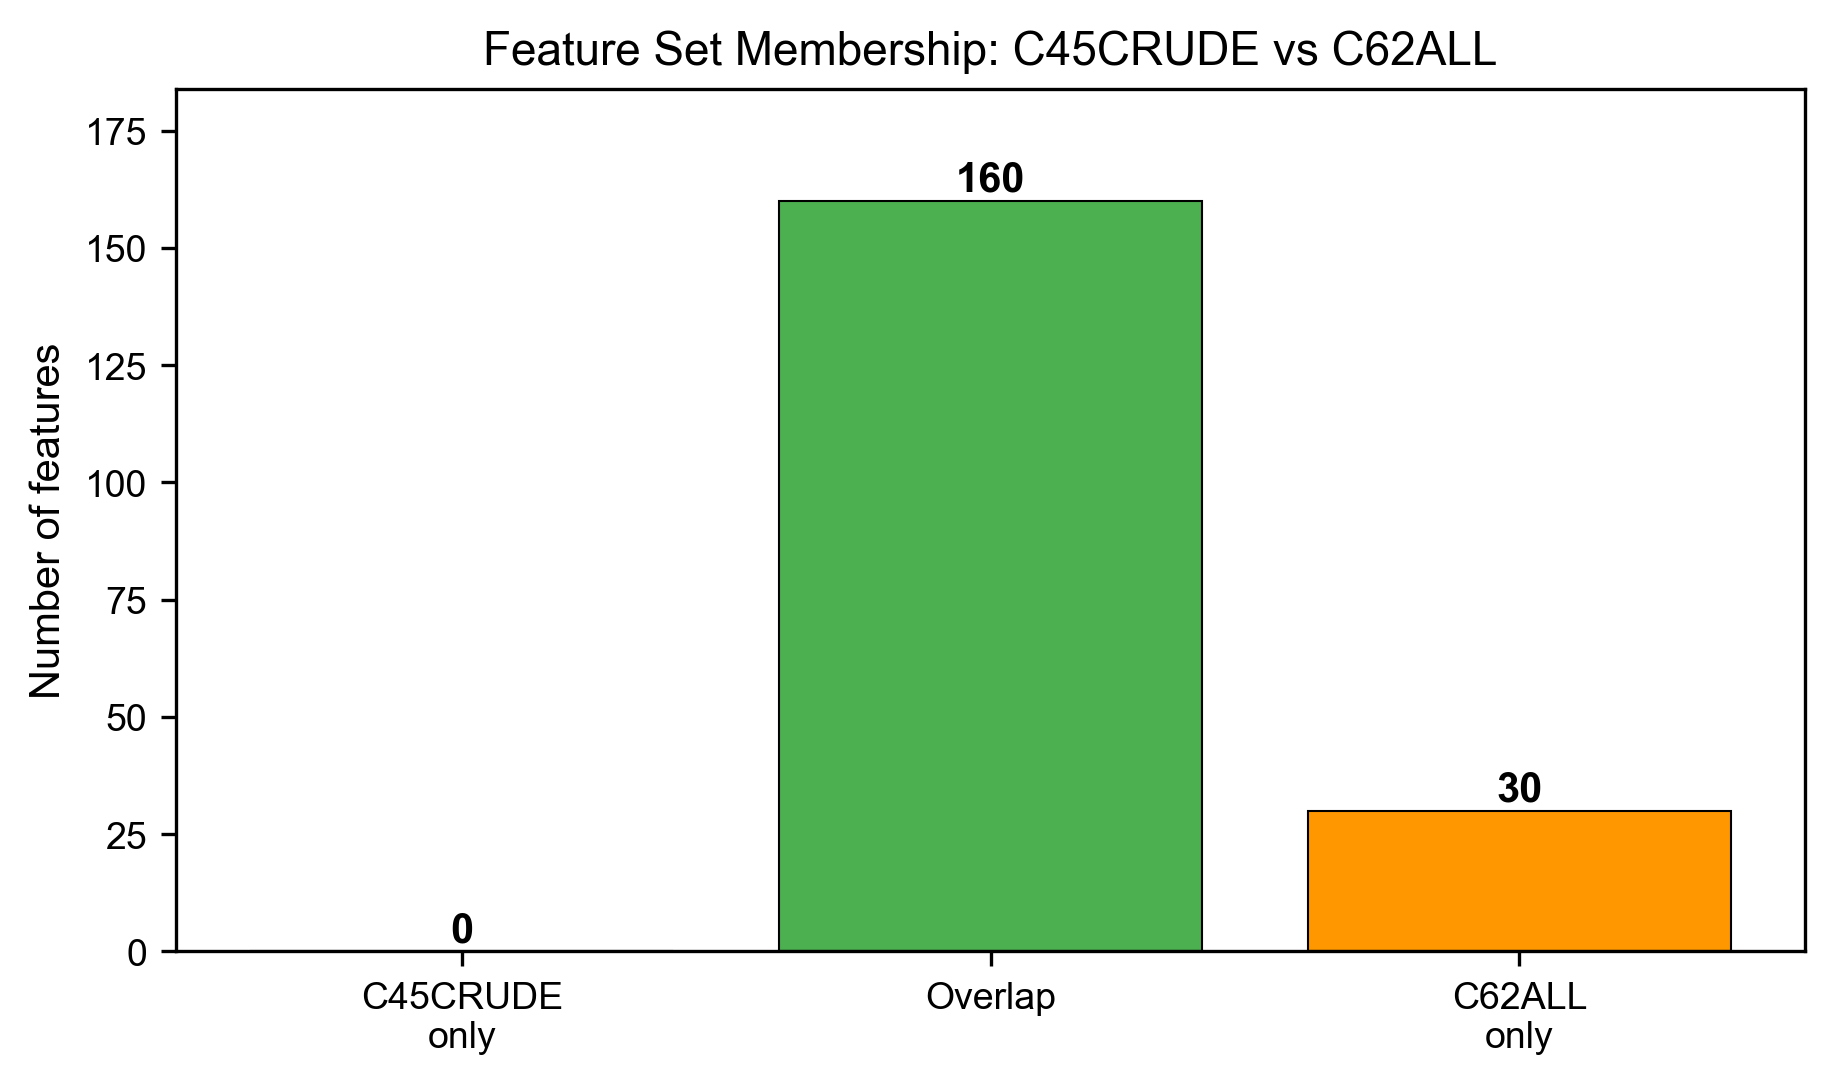

F1 saved.


In [5]:
# Cell 6 — F1 Feature set membership (bar chart)
# matplotlib_venn not installed; use bar chart showing set membership counts

try:
    fig, ax = plt.subplots(figsize=(6, 3.5))

    categories = ['C45CRUDE\nonly', 'Overlap', 'C62ALL\nonly']
    counts = [len(c45_only), len(overlap), len(c62_only)]
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(count), ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Number of features')
    ax.set_title('Feature Set Membership: C45CRUDE vs C62ALL')
    ax.set_ylim(0, max(counts) * 1.15)

    fig.savefig(FIG_DIR / 'F1_feature_set_membership.png', bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(FIG_DIR / 'F1_feature_set_membership.png')))
    print('F1 saved.')
except Exception as e:
    print(f'F1 figure failed: {e}')

## S3 — Two-Pass Correlation Filter

Remove redundant features using |Pearson r| > 0.95 threshold.

**Pass 1:** canonical-vs-canonical pairs (keep the one with lower W0 variance).
**Pass 2:** exploratory-vs-canonical (remove exploratory) and exploratory-vs-exploratory
(keep the one with lower W0 variance).

Protected pairs from `feature_conditional_value` are never broken.

In [6]:
# Cell 8 — Build X matrix for W0 (feature values)

# Identify which feature names are compounds vs ratios
compound_set = set(
    pd.read_sql("SELECT compound_name FROM compounds WHERE excluded=0", conn)['compound_name']
)
ratio_set = set(
    pd.read_sql("SELECT DISTINCT ratio_name FROM diagnostic_ratios", conn)['ratio_name']
)


def fetch_feature_matrix(feature_names, stage_code='W0', crude_only=True):
    """
    Build a (oils x features) DataFrame from measurements + diagnostic_ratios.
    
    Parameters
    ----------
    feature_names : set or list
        Feature names to include.
    stage_code : str
        Weathering stage (default 'W0').
    crude_only : bool
        If True, restrict to crude oils only.
    
    Returns
    -------
    pd.DataFrame
        Rows = oil_id, Columns = feature_name, Values = numeric.
    """
    feature_names = set(feature_names)
    oil_filter = "AND o.oil_type = 'crude'" if crude_only else ''
    
    compound_features = sorted(feature_names & compound_set)
    ratio_features = sorted(feature_names & ratio_set)
    
    dfs = []
    
    if compound_features:
        placeholders = ','.join('?' * len(compound_features))
        q = f"""
        SELECT m.oil_id, c.compound_name AS feature_name, m.value_imputed AS value
        FROM measurements m
        JOIN oils o ON m.oil_id = o.oil_id
        JOIN compounds c ON m.compound_id = c.compound_id
        WHERE m.stage_code = ? AND o.include_in_analysis = 1 {oil_filter}
          AND c.compound_name IN ({placeholders})
        """
        dfs.append(pd.read_sql(q, conn, params=[stage_code] + compound_features))
    
    if ratio_features:
        placeholders = ','.join('?' * len(ratio_features))
        q = f"""
        SELECT dr.oil_id, dr.ratio_name AS feature_name, dr.value
        FROM diagnostic_ratios dr
        JOIN oils o ON dr.oil_id = o.oil_id
        WHERE dr.stage_code = ? AND o.include_in_analysis = 1 {oil_filter}
          AND dr.ratio_name IN ({placeholders})
        """
        dfs.append(pd.read_sql(q, conn, params=[stage_code] + ratio_features))
    
    if not dfs:
        return pd.DataFrame()
    
    df = pd.concat(dfs, ignore_index=True)
    return df.pivot_table(index='oil_id', columns='feature_name', values='value')


# Build W0 matrix for C45CRUDE
X_c45_w0 = fetch_feature_matrix(CANDIDATES_C45CRUDE, stage_code='W0', crude_only=True)
print(f'X_c45_w0 shape: {X_c45_w0.shape}  (oils x features)')
print(f'NaN fraction: {X_c45_w0.isna().mean().mean():.4f}')

# Build W0 matrix for C62ALL
X_c62_w0 = fetch_feature_matrix(CANDIDATES_C62ALL, stage_code='W0', crude_only=False)
print(f'X_c62_w0 shape: {X_c62_w0.shape}  (oils x features)')
print(f'NaN fraction: {X_c62_w0.isna().mean().mean():.4f}')

X_c45_w0 shape: (42, 160)  (oils x features)
NaN fraction: 0.0103
X_c62_w0 shape: (59, 190)  (oils x features)
NaN fraction: 0.0759


In [7]:
# Cell 9 — Identify canonical features (spec-conformant: normative ratios only)
#
# Canonical = CEN EN 15522-2 ratios
#           + classical isoprenoid ratios (Pr_Ph, Pr_nC17, Ph_nC18)
#
# Rationale: "canonical" encodes forensic normative status, not measurement
# primacy. Compounds are direct measurements but lack standardized
# cross-laboratory calibration like CEN ratios do. Keeping compounds in the
# exploratory tier preserves the hierarchy: normative ratios beat derived
# quantities in Pass 2a without CV tiebreak (priority, not statistics).

rd = pd.read_sql("""
    SELECT ratio_name, category, cen_reference
    FROM ratio_definitions
""", conn)

# CEN normative ratios (Douglas 1996 ratios D3/P3, D3/C3 are 'exploratory' per NB02 F-NB02-L3 — filtered on empirical metrics, not canonical pedigree)
canonical_ratios = set(
    rd.loc[(rd['category'] == 'canonical') | (rd['cen_reference'].notna()), 'ratio_name']
)

# Classical isoprenoid ratios (add only if present in DB)
isoprenoid_ratios = {'Pr_Ph', 'Pr_nC17', 'Ph_nC18'} & set(rd['ratio_name'])

canonical_features = canonical_ratios | isoprenoid_ratios
print(f'Canonical features (normative ratios only):')
print(f'  CEN normative ratios from ratio_definitions: {len(canonical_ratios)}')
print(f'  Isoprenoid (present in DB):           {len(isoprenoid_ratios)}')
print(f'  Total canonical:                      {len(canonical_features)}')
print(f'\nCompounds ({len(compound_set)}) treated as exploratory (Pass 2).')

Canonical features (normative ratios only):
  CEN normative ratios from ratio_definitions: 32
  Isoprenoid (present in DB):           1
  Total canonical:                      32

Compounds (92) treated as exploratory (Pass 2).


In [8]:
# Cell 10 — Tiebreak function (W0 CV — on-the-fly)
# feature_consistency.cv_w0 is empty in current DB state. Computing CV
# directly from the W0 matrix restores scale-invariance of the tiebreak:
# lower CV = more consistent across oils relative to own mean.
#
# Guards:
#   - Mean near zero -> CV explodes. Fallback: use std (absolute spread).
#   - Result inf/-inf -> replaced by NaN.
#   - Features missing from matrix -> default np.inf (never wins tiebreak).

def _compute_cv_w0(X_w0, eps=1e-10):
    """Per-feature CV on the W0 matrix.

    CV = std / |mean| where |mean| > eps; else fallback to std.
    Returns pd.Series indexed by feature name.
    """
    mean_abs = X_w0.mean().abs()
    std = X_w0.std(ddof=0)
    cv = std / mean_abs.where(mean_abs > eps, np.nan)
    # Fallback: where |mean| is too small, use raw std (same scale family)
    cv = cv.where(cv.notna(), std)
    return cv.replace([np.inf, -np.inf], np.nan)


w0_cv_c45 = _compute_cv_w0(X_c45_w0)
w0_cv_c62 = _compute_cv_w0(X_c62_w0)

# Diagnostic
_std_c45 = X_c45_w0.std(ddof=0)
_std_c62 = X_c62_w0.std(ddof=0)
n_fallback_c45 = int((w0_cv_c45 == _std_c45).sum())
n_fallback_c62 = int((w0_cv_c62 == _std_c62).sum())
print(f'C45 CV: {w0_cv_c45.notna().sum()}/{len(w0_cv_c45)} computed '
      f'({n_fallback_c45} fallback-to-std for mean<{1e-10:.0e})')
print(f'C62 CV: {w0_cv_c62.notna().sum()}/{len(w0_cv_c62)} computed '
      f'({n_fallback_c62} fallback-to-std)')


def pick_winner(a, b, w0_cv):
    """Given two correlated features, pick which to KEEP.

    Tiebreak: lower W0 CV wins (more stable relative to own magnitude).
    NaN CVs treated as infinite (never win).
    If CVs equal, keep alphabetically first (deterministic).
    """
    cv_a = w0_cv.get(a, np.inf)
    cv_b = w0_cv.get(b, np.inf)
    if pd.isna(cv_a): cv_a = np.inf
    if pd.isna(cv_b): cv_b = np.inf
    if cv_a < cv_b:
        return a, b
    elif cv_b < cv_a:
        return b, a
    else:
        return (a, b) if a < b else (b, a)


print(f'\nTiebreak: lower W0 CV = keep (scale-invariant).')

C45 CV: 160/160 computed (0 fallback-to-std for mean<1e-10)
C62 CV: 190/190 computed (0 fallback-to-std)

Tiebreak: lower W0 CV = keep (scale-invariant).


In [9]:
# Cell 11 — Two-pass correlation filter (C45CRUDE)

def correlation_filter(X_w0, candidates, canonical_set, w0_cv,
                       threshold=CORR_THRESHOLD, protected=PROTECTED_PAIRS):
    """Two-pass correlation filter.

    Pass 1: canonical-vs-canonical. Keep lower-CV feature.
    Pass 2a: exploratory-vs-canonical (canonical wins by priority).
    Pass 2b: exploratory-vs-exploratory (keep lower-CV).

    Protected features (members of ANY protected pair) are NEVER removed.
    Protected skips are logged for audit trail.
    """
    # Build set of ALL features that are members of any protected pair
    protected_members = set()
    for pair in protected:
        for f in pair:
            if f in candidates:
                protected_members.add(f)
    print(f'  Protected members (immune to removal): {len(protected_members)}')

    # Only use features present in the matrix
    available = sorted(candidates & set(X_w0.columns))
    X = X_w0[available].dropna(axis=1, how='all')
    available = list(X.columns)

    # Compute correlation matrix (pairwise complete obs)
    corr = X.corr(method='pearson')

    removed = set()
    log = []
    order = 0

    def _cv(feature):
        v = w0_cv.get(feature, np.nan)
        return None if pd.isna(v) else float(round(v, 6))

    # Pass 1: canonical vs canonical
    canon_avail = [f for f in available if f in canonical_set]
    for i, fa in enumerate(canon_avail):
        if fa in removed:
            continue
        for fb in canon_avail[i+1:]:
            if fb in removed:
                continue
            r_val = corr.loc[fa, fb]
            if pd.isna(r_val) or abs(r_val) <= threshold:
                continue
            winner, loser = pick_winner(fa, fb, w0_cv)
            # Never remove a protected member
            if loser in protected_members:
                if winner in protected_members:
                    # Both protected: skip entirely; log for audit
                    order += 1
                    log.append({
                        'pass': 1,
                        'removed_feature': None,
                        'kept_feature': None,
                        'pearson_r': float(round(r_val, 6)),
                        'cv_removed': None,
                        'cv_kept': None,
                        'removal_order': order,
                        'protected_flag': 1,
                        'notes': f'both_protected:{fa}|{fb}',
                    })
                    continue
                else:
                    loser, winner = winner, loser
            removed.add(loser)
            order += 1
            log.append({
                'pass': 1,
                'removed_feature': loser,
                'kept_feature': winner,
                'pearson_r': float(round(r_val, 6)),
                'cv_removed': _cv(loser),
                'cv_kept': _cv(winner),
                'removal_order': order,
                'protected_flag': 0,
                'notes': None,
            })

    pass1_count = len([l for l in log if l['pass'] == 1 and l['removed_feature'] is not None])
    print(f'  Pass 1 (canon vs canon): removed {pass1_count} features')

    # Pass 2: exploratory vs canonical survivors, then exp vs exp
    exp_avail = [f for f in available if f not in canonical_set and f not in removed]
    canon_survivors = [f for f in canon_avail if f not in removed]

    # 2a: exploratory vs canonical (remove exploratory)
    for fe in exp_avail[:]:
        if fe in removed:
            continue
        if fe in protected_members:
            # Protected exploratory: log skip for audit
            order += 1
            log.append({
                'pass': 2,
                'removed_feature': None,
                'kept_feature': None,
                'pearson_r': None,
                'cv_removed': None,
                'cv_kept': None,
                'removal_order': order,
                'protected_flag': 1,
                'notes': f'protected_exploratory:{fe}',
            })
            continue
        for fc in canon_survivors:
            if fc in removed:
                continue
            r_val = corr.loc[fe, fc]
            if pd.isna(r_val) or abs(r_val) <= threshold:
                continue
            removed.add(fe)
            order += 1
            log.append({
                'pass': 2,
                'removed_feature': fe,
                'kept_feature': fc,
                'pearson_r': float(round(r_val, 6)),
                'cv_removed': _cv(fe),
                'cv_kept': _cv(fc),
                'removal_order': order,
                'protected_flag': 0,
                'notes': None,
            })
            break  # feature already removed, skip remaining canons

    # 2b: exploratory vs exploratory
    exp_remaining = [f for f in exp_avail if f not in removed]
    for i, fa in enumerate(exp_remaining):
        if fa in removed:
            continue
        for fb in exp_remaining[i+1:]:
            if fb in removed:
                continue
            r_val = corr.loc[fa, fb]
            if pd.isna(r_val) or abs(r_val) <= threshold:
                continue
            winner, loser = pick_winner(fa, fb, w0_cv)
            # Never remove a protected member
            if loser in protected_members:
                if winner in protected_members:
                    order += 1
                    log.append({
                        'pass': 2,
                        'removed_feature': None,
                        'kept_feature': None,
                        'pearson_r': float(round(r_val, 6)),
                        'cv_removed': None,
                        'cv_kept': None,
                        'removal_order': order,
                        'protected_flag': 1,
                        'notes': f'both_protected:{fa}|{fb}',
                    })
                    continue
                else:
                    loser, winner = winner, loser
            removed.add(loser)
            order += 1
            log.append({
                'pass': 2,
                'removed_feature': loser,
                'kept_feature': winner,
                'pearson_r': float(round(r_val, 6)),
                'cv_removed': _cv(loser),
                'cv_kept': _cv(winner),
                'removal_order': order,
                'protected_flag': 0,
                'notes': None,
            })

    pass2_count = len([l for l in log if l['pass'] == 2 and l['removed_feature'] is not None])
    print(f'  Pass 2 (exp vs canon + exp vs exp): removed {pass2_count} features')

    survivors = candidates - removed
    return survivors, log


# Run for C45CRUDE
print('Correlation filter: C45CRUDE')
print(f'  Candidates: {len(CANDIDATES_C45CRUDE)}')
SURVIVORS_C45, LOG_C45 = correlation_filter(
    X_c45_w0, CANDIDATES_C45CRUDE, canonical_features, w0_cv_c45
)
print(f'  Survivors: {len(SURVIVORS_C45)} ({len(CANDIDATES_C45CRUDE) - len(SURVIVORS_C45)} removed)')

# Verify protected pairs are intact
for pair in PROTECTED_PAIRS:
    a, b = list(pair)
    if a in CANDIDATES_C45CRUDE and b in CANDIDATES_C45CRUDE:
        assert a in SURVIVORS_C45 and b in SURVIVORS_C45, \
            f'Protected pair broken: {a}, {b}'
print('  Protected pairs: ALL INTACT')

Correlation filter: C45CRUDE
  Candidates: 160
  Protected members (immune to removal): 12
  Pass 1 (canon vs canon): removed 1 features
  Pass 2 (exp vs canon + exp vs exp): removed 40 features
  Survivors: 127 (33 removed)
  Protected pairs: ALL INTACT


In [10]:
# Cell 12 — Show removal log for C45CRUDE

if LOG_C45:
    df_log_c45 = pd.DataFrame(LOG_C45)
    print(f'C45CRUDE removal log: {len(df_log_c45)} entries')
    print(f'  Pass 1 removals: {(df_log_c45["pass"] == 1).sum()}')
    print(f'  Pass 2 removals: {(df_log_c45["pass"] == 2).sum()}')
    print()
    print(df_log_c45[['removed_feature', 'kept_feature', 'pearson_r', 'pass']]
          .to_string(index=False))
else:
    print('No features removed by correlation filter (C45CRUDE).')

C45CRUDE removal log: 53 entries
  Pass 1 removals: 2
  Pass 2 removals: 51

                removed_feature                   kept_feature  pearson_r  pass
                    C2DBT_C2Phe                    C1DBT_C1Phe   0.980799     1
                           None                           None   0.992512     1
                           None                           None        NaN     2
                           None                           None        NaN     2
                           None                           None        NaN     2
                    C0DBT_C1DBT                    C0DBT_C3DBT   0.972299     2
                    C0DBT_C2DBT                    C0DBT_C3DBT   0.980952     2
                    C0Flu_C2Flu                    C0Flu_C3Flu   0.952401     2
                           None                           None        NaN     2
                  C0Naph_C3Naph                  C0Naph_C4Naph   0.971770     2
                           None            

In [11]:
# Cell 13 — Persist correlation_filter_log (schema with config, pass_number, protected_flag)

cur.execute("""
CREATE TABLE IF NOT EXISTS correlation_filter_log (
    pair_id          INTEGER PRIMARY KEY AUTOINCREMENT,
    config           TEXT    NOT NULL,
    pass_number      INTEGER NOT NULL,
    threshold        REAL,
    removed_feature  TEXT,
    kept_feature     TEXT,
    pearson_r        REAL,
    cv_removed       REAL,
    cv_kept          REAL,
    removal_order    INTEGER,
    protected_flag   INTEGER DEFAULT 0,
    notes            TEXT
)
""")

# Insert C45CRUDE log entries
for entry in LOG_C45:
    cur.execute("""
    INSERT INTO correlation_filter_log
        (config, pass_number, threshold, removed_feature, kept_feature,
         pearson_r, cv_removed, cv_kept, removal_order, protected_flag, notes)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        'C45CRUDE',
        entry['pass'],
        CORR_THRESHOLD,
        entry.get('removed_feature'),
        entry.get('kept_feature'),
        entry.get('pearson_r'),
        entry.get('cv_removed'),
        entry.get('cv_kept'),
        entry['removal_order'],
        entry.get('protected_flag', 0),
        entry.get('notes'),
    ))

conn.commit()
cur.execute('SELECT COUNT(*) FROM correlation_filter_log')
print(f'correlation_filter_log: {cur.fetchone()[0]} rows persisted (C45CRUDE)')

correlation_filter_log: 53 rows persisted (C45CRUDE)


In [12]:
# Cell 14 — Repeat correlation filter for C62ALL

print('Correlation filter: C62ALL')
print(f'  Candidates: {len(CANDIDATES_C62ALL)}')
SURVIVORS_C62, LOG_C62 = correlation_filter(
    X_c62_w0, CANDIDATES_C62ALL, canonical_features, w0_cv_c62
)
print(f'  Survivors: {len(SURVIVORS_C62)} ({len(CANDIDATES_C62ALL) - len(SURVIVORS_C62)} removed)')

# Verify protected pairs intact for C62ALL
for pair in PROTECTED_PAIRS:
    a, b = list(pair)
    if a in CANDIDATES_C62ALL and b in CANDIDATES_C62ALL:
        assert a in SURVIVORS_C62 and b in SURVIVORS_C62, \
            f'Protected pair broken (C62): {a}, {b}'
print('  Protected pairs: ALL INTACT')

# Append C62ALL log using same schema (config column disambiguates)
for entry in LOG_C62:
    cur.execute("""
    INSERT INTO correlation_filter_log
        (config, pass_number, threshold, removed_feature, kept_feature,
         pearson_r, cv_removed, cv_kept, removal_order, protected_flag, notes)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        'C62ALL',
        entry['pass'],
        CORR_THRESHOLD,
        entry.get('removed_feature'),
        entry.get('kept_feature'),
        entry.get('pearson_r'),
        entry.get('cv_removed'),
        entry.get('cv_kept'),
        entry['removal_order'],
        entry.get('protected_flag', 0),
        entry.get('notes'),
    ))

conn.commit()
cur.execute('SELECT COUNT(*) FROM correlation_filter_log')
print(f'\ncorrelation_filter_log total: {cur.fetchone()[0]} rows')

Correlation filter: C62ALL
  Candidates: 190
  Protected members (immune to removal): 19
  Pass 1 (canon vs canon): removed 3 features
  Pass 2 (exp vs canon + exp vs exp): removed 50 features
  Survivors: 142 (48 removed)
  Protected pairs: ALL INTACT

correlation_filter_log total: 136 rows


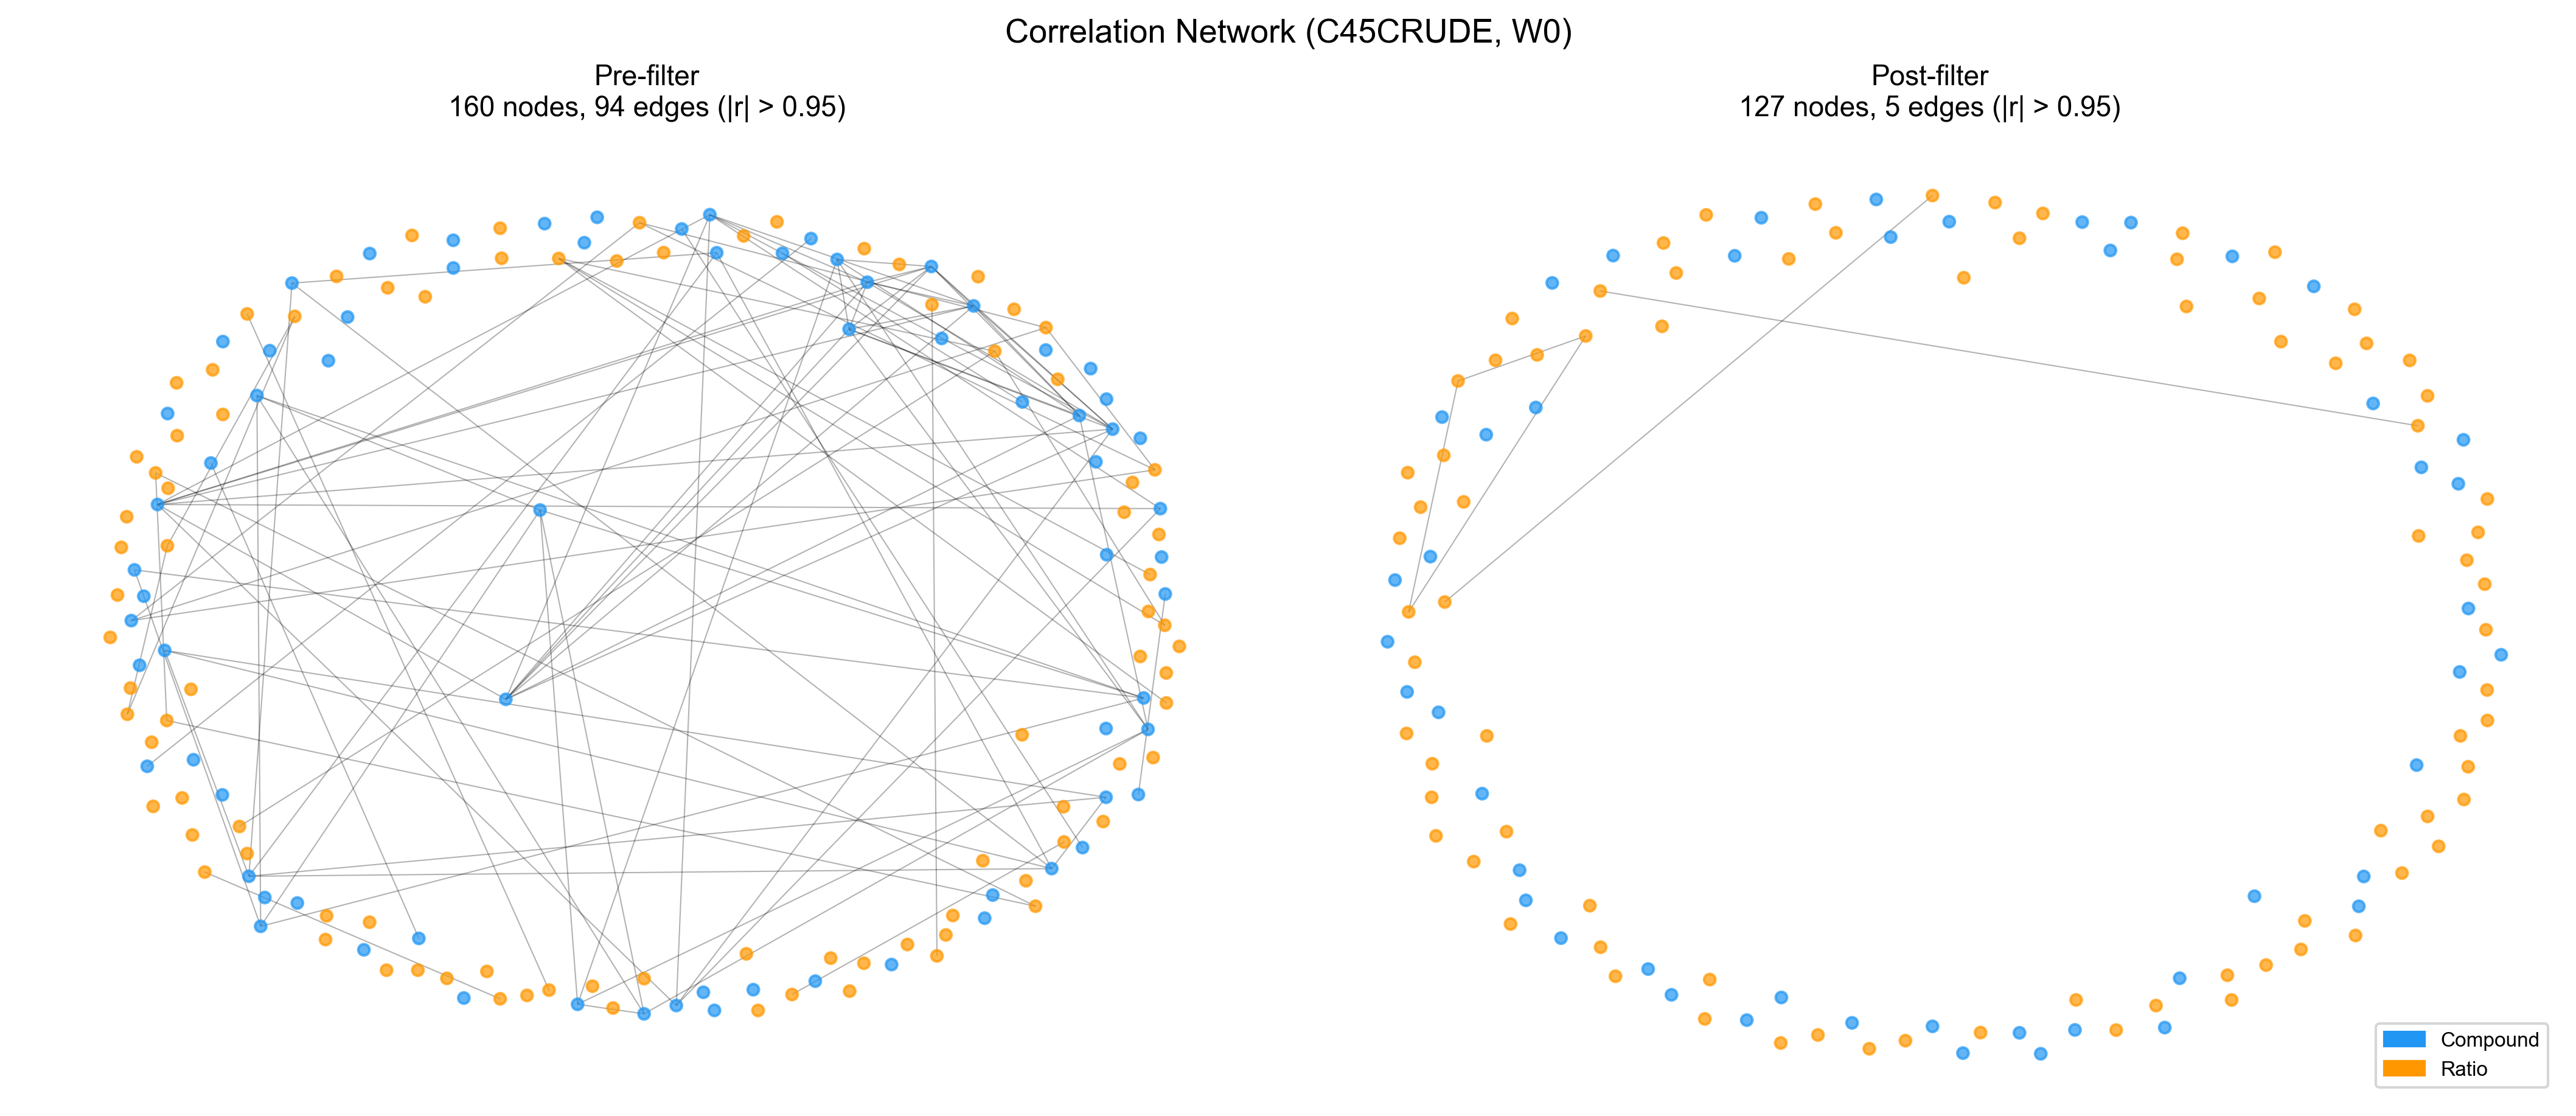

F2 saved.


In [13]:
# Cell 15 — F2 Network graph: pre/post correlation filter (C45CRUDE)

try:
    # Pre-filter: all pairs with |r| > threshold
    X_pre = X_c45_w0[sorted(CANDIDATES_C45CRUDE & set(X_c45_w0.columns))]
    corr_pre = X_pre.corr(method='pearson')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax_idx, (title, feat_set) in enumerate([
        ('Pre-filter', CANDIDATES_C45CRUDE),
        ('Post-filter', SURVIVORS_C45),
    ]):
        ax = axes[ax_idx]
        available = sorted(feat_set & set(corr_pre.columns))
        G = nx.Graph()
        G.add_nodes_from(available)
        
        for i, fa in enumerate(available):
            for fb in available[i+1:]:
                r_val = corr_pre.loc[fa, fb] if fa in corr_pre.index and fb in corr_pre.columns else np.nan
                if not pd.isna(r_val) and abs(r_val) > CORR_THRESHOLD:
                    G.add_edge(fa, fb, weight=abs(r_val))
        
        n_edges = G.number_of_edges()
        n_nodes = G.number_of_nodes()
        
        # Color nodes by type
        colors = ['#2196F3' if n in compound_set else '#FF9800' for n in G.nodes()]
        
        if n_edges > 0:
            pos = nx.spring_layout(G, seed=SEED, k=2.0)
            nx.draw_networkx_nodes(G, pos, ax=ax, node_size=20, node_color=colors, alpha=0.7)
            nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=0.5)
        else:
            ax.text(0.5, 0.5, 'No edges above threshold', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
        
        ax.set_title(f'{title}\n{n_nodes} nodes, {n_edges} edges (|r| > {CORR_THRESHOLD})')
        ax.axis('off')
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='#2196F3', label='Compound'),
        mpatches.Patch(color='#FF9800', label='Ratio'),
    ]
    axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    fig.suptitle('Correlation Network (C45CRUDE, W0)', fontsize=13)
    fig.savefig(FIG_DIR / 'F2_correlation_network.png', bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(FIG_DIR / 'F2_correlation_network.png')))
    print('F2 saved.')
except Exception as e:
    print(f'F2 figure failed: {e}')
    import traceback; traceback.print_exc()

VIF input: n=42 samples, p=92 features

*** VIF skipped: p=92 >= n=42 ***
    When p >= n, the OLS regression for VIF becomes singular,
    returning VIF = inf for all features regardless of actual
    multicollinearity. This is a structural limitation of the
    crude W0 subset (44 oils, ~100 features), not a data issue.
    Multicollinearity inspection deferred to NB06 SHAP analysis.


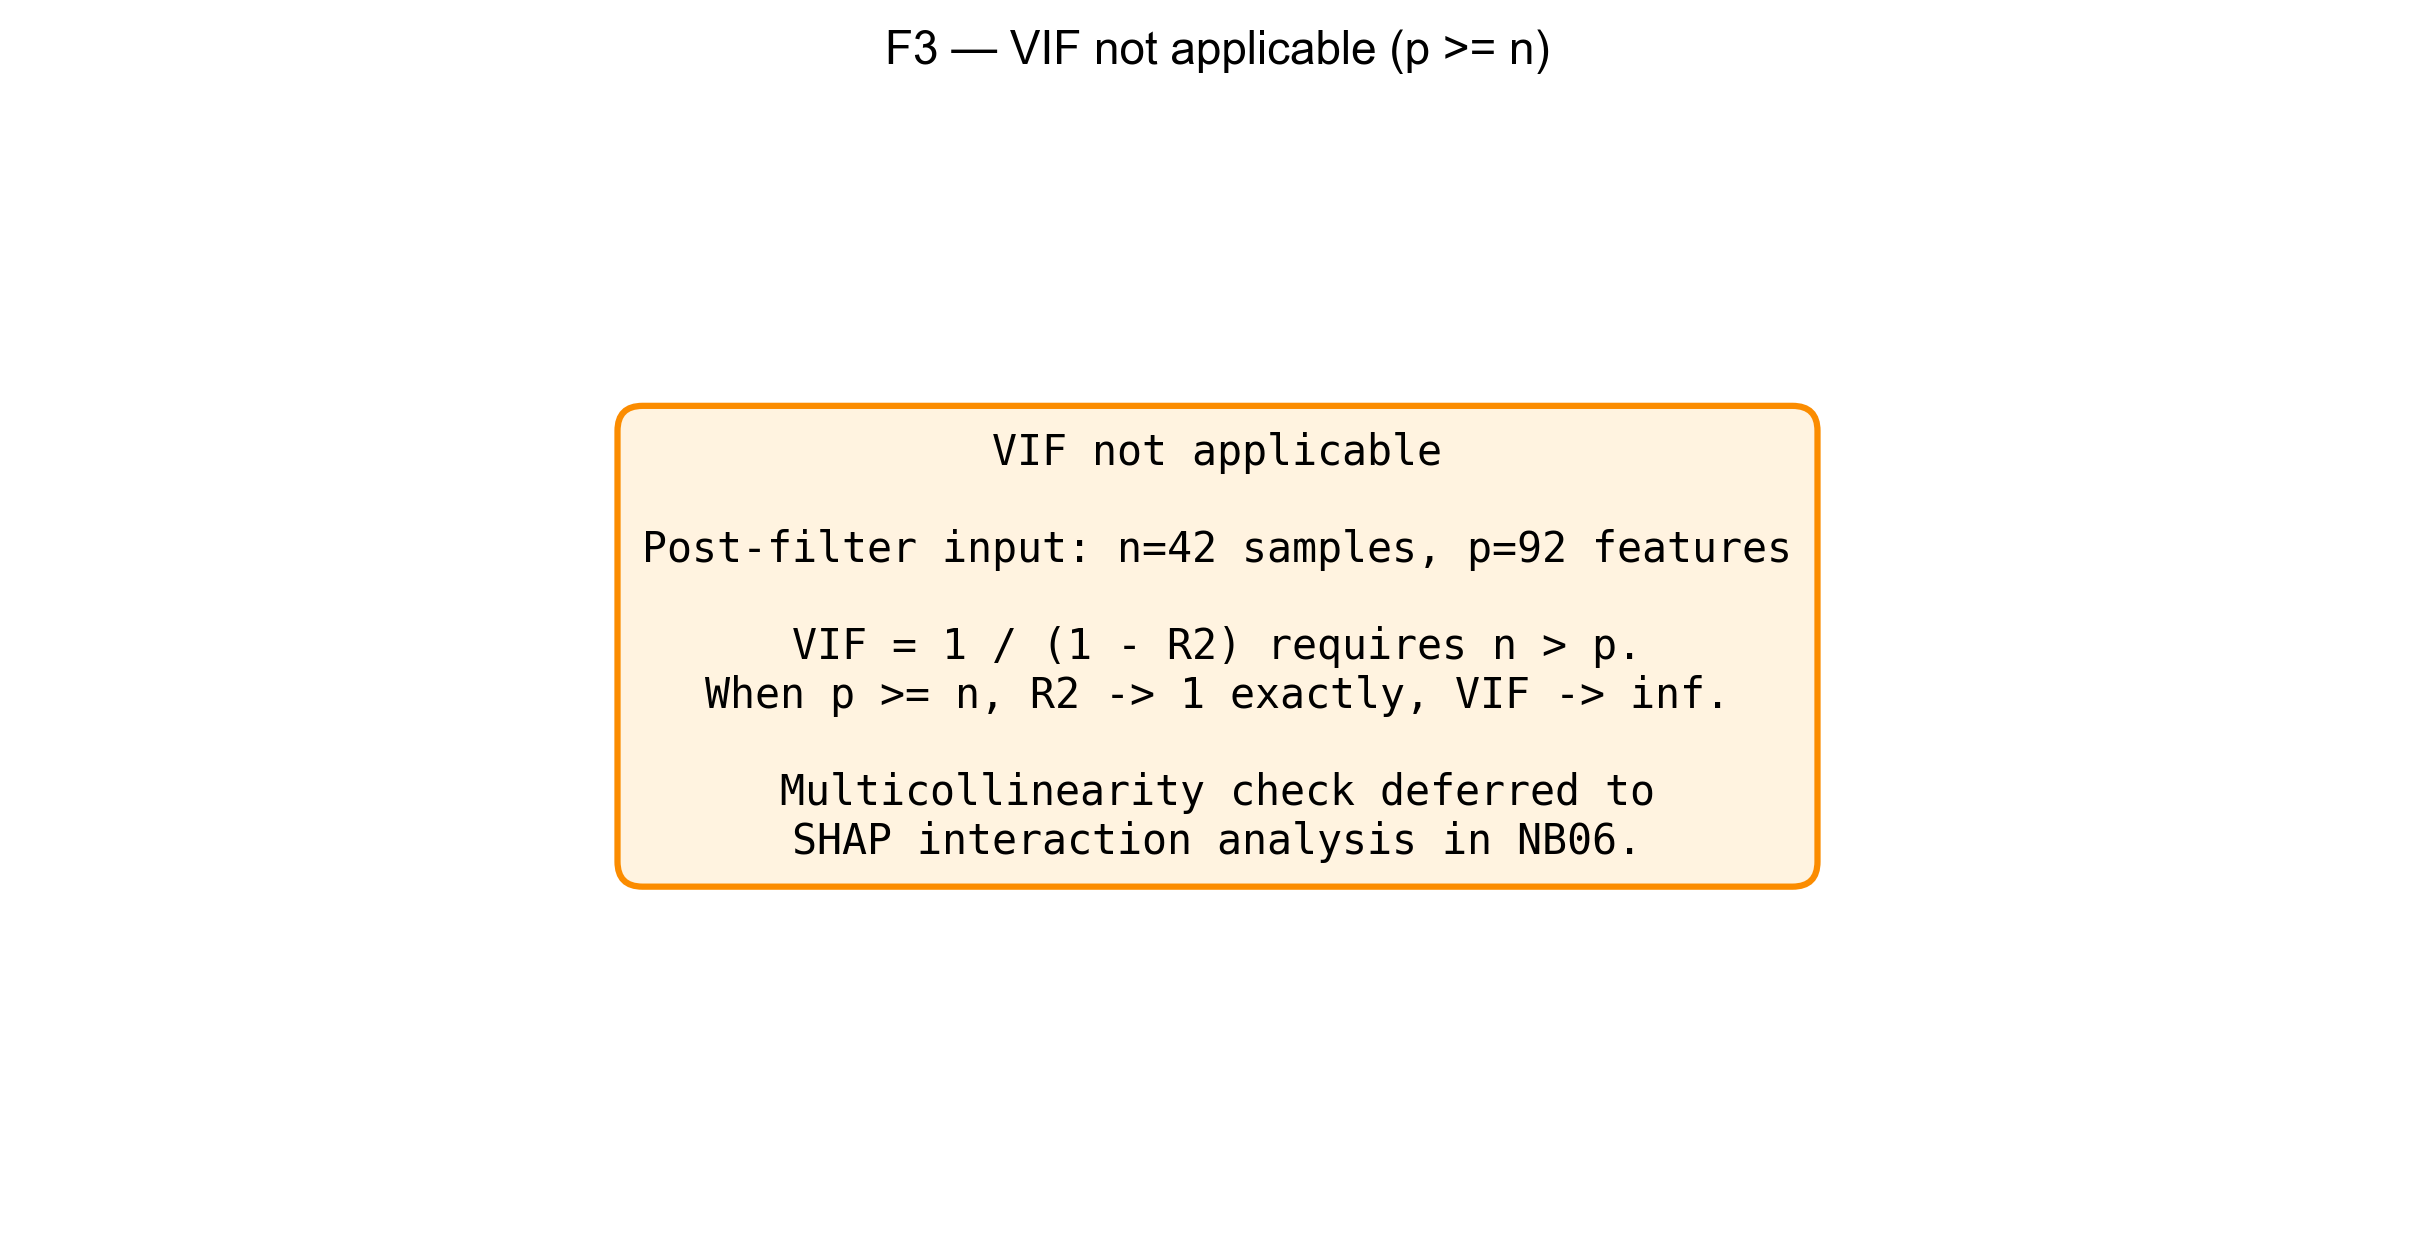

F3 placeholder saved.


In [14]:
# Cell 16 — F3 VIF top-20 (Variance Inflation Factor)
# VIF = 1 / (1 - R^2_j), where R^2_j is from regressing feature j on all others.
#
# LIMITATION: VIF requires n > p (samples > features) for the internal regression
# to be non-singular. When p >= n, R^2_j -> 1 and VIF -> inf for all features,
# making the metric uninformative. In that case we skip VIF and defer
# multicollinearity inspection to NB06's SHAP interaction analysis.

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # Use C45CRUDE survivors, W0 only, drop NaN columns
    X_vif = X_c45_w0[sorted(SURVIVORS_C45 & set(X_c45_w0.columns))].dropna(axis=1)
    n, p = X_vif.shape
    print(f'VIF input: n={n} samples, p={p} features')
    
    if p >= n:
        # Singular regression: VIF is not computable/informative
        print(f'\n*** VIF skipped: p={p} >= n={n} ***')
        print(f'    When p >= n, the OLS regression for VIF becomes singular,')
        print(f'    returning VIF = inf for all features regardless of actual')
        print(f'    multicollinearity. This is a structural limitation of the')
        print(f'    crude W0 subset (44 oils, ~100 features), not a data issue.')
        print(f'    Multicollinearity inspection deferred to NB06 SHAP analysis.')
        
        # Save a placeholder figure documenting the limitation for the SI
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.text(0.5, 0.5,
                f'VIF not applicable\n\n'
                f'Post-filter input: n={n} samples, p={p} features\n\n'
                f'VIF = 1 / (1 - R2) requires n > p.\n'
                f'When p >= n, R2 -> 1 exactly, VIF -> inf.\n\n'
                f'Multicollinearity check deferred to\n'
                f'SHAP interaction analysis in NB06.',
                ha='center', va='center', fontsize=10, transform=ax.transAxes,
                family='monospace',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFF3E0',
                          edgecolor='#FB8C00', linewidth=1.5))
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title('F3 — VIF not applicable (p >= n)', fontsize=11)
        ax.axis('off')
        fig.savefig(FIG_DIR / 'F3_vif_top20.png', bbox_inches='tight')
        plt.close(fig)
        display(Image(filename=str(FIG_DIR / 'F3_vif_top20.png')))
        print('F3 placeholder saved.')
    elif p > 1:
        # Standardize for VIF stability
        X_scaled = StandardScaler().fit_transform(X_vif)
        
        vif_data = []
        for i in range(X_scaled.shape[1]):
            try:
                vif_val = variance_inflation_factor(X_scaled, i)
            except Exception:
                vif_val = np.nan
            vif_data.append({'feature': X_vif.columns[i], 'VIF': vif_val})
        
        df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
        df_vif_top20 = df_vif.head(20)
        
        print('Top-20 VIF values (post-filter, C45CRUDE W0):')
        print(df_vif_top20.to_string(index=False))
        
        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ['#e53935' if v > 10 else '#FFC107' if v > 5 else '#4CAF50'
                  for v in df_vif_top20['VIF']]
        ax.barh(range(len(df_vif_top20)), df_vif_top20['VIF'].values,
                color=colors, edgecolor='black', linewidth=0.3)
        ax.set_yticks(range(len(df_vif_top20)))
        ax.set_yticklabels(df_vif_top20['feature'].values, fontsize=8)
        ax.set_xlabel('Variance Inflation Factor')
        ax.set_title(f'Top-20 VIF (post-filter, C45CRUDE W0, n={n}, p={p})')
        ax.axvline(x=10, color='red', linestyle='--', linewidth=0.8, label='VIF=10')
        ax.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, label='VIF=5')
        ax.legend(fontsize=8)
        ax.invert_yaxis()
        
        fig.savefig(FIG_DIR / 'F3_vif_top20.png', bbox_inches='tight')
        plt.close(fig)
        display(Image(filename=str(FIG_DIR / 'F3_vif_top20.png')))
        print('F3 saved.')
    else:
        print('Not enough features for VIF computation.')
except ImportError:
    print('statsmodels not installed; skipping VIF computation.')
except Exception as e:
    print(f'F3 figure failed: {e}')
    import traceback; traceback.print_exc()

## S4 — OOD Envelope

Compute out-of-distribution (OOD) reference ranges per feature per oil_type
from W0 data. These ranges flag when a new sample falls outside the training
envelope, which is critical for forensic deployment.

In [15]:
# Cell 18 — OOD compute + persist lgaf_ood_ranges (spec-conformant schema)

# Get oil_type per oil_id
oil_types = pd.read_sql("""
    SELECT oil_id, oil_type FROM oils WHERE include_in_analysis = 1
""", conn)

# Build full W0 matrix for all included oils (C62ALL scope)
all_features = SURVIVORS_C45 | SURVIVORS_C62
X_all_w0 = fetch_feature_matrix(all_features, stage_code='W0', crude_only=False)
X_all_w0 = X_all_w0.merge(oil_types.set_index('oil_id'), left_index=True, right_index=True)

print(f'All survivors union: {len(all_features)} features')
print(f'X_all_w0 shape: {X_all_w0.shape}')

# Create lgaf_ood_ranges table (spec-conformant: min/q05/q25/median/q75/q95/max/iqr bounds)
cur.execute("""
CREATE TABLE IF NOT EXISTS lgaf_ood_ranges (
    feature_name   TEXT    NOT NULL,
    oil_type       TEXT    NOT NULL,
    n_samples_w0   INTEGER NOT NULL,
    min_value      REAL,
    q05            REAL,
    q25            REAL,
    median         REAL,
    q75            REAL,
    q95            REAL,
    max_value      REAL,
    iqr_lower      REAL,
    iqr_upper      REAL,
    PRIMARY KEY (feature_name, oil_type)
)
""")

ood_records = []
feature_cols = [c for c in X_all_w0.columns if c != 'oil_type']

# Per feature x oil_type + one 'all' bucket per feature (global bounds)
for feat in sorted(feature_cols):
    for otype in list(sorted(X_all_w0['oil_type'].unique())) + ['all']:
        if otype == 'all':
            vals = X_all_w0[feat].dropna()
        else:
            vals = X_all_w0.loc[X_all_w0['oil_type'] == otype, feat].dropna()
        if len(vals) < 3:
            continue
        q05, q25, q75, q95 = np.quantile(vals, [0.05, 0.25, 0.75, 0.95])
        iqr = q75 - q25
        ood_records.append((
            feat,
            otype,
            int(len(vals)),
            float(vals.min()),
            float(q05),
            float(q25),
            float(vals.median()),
            float(q75),
            float(q95),
            float(vals.max()),
            float(q25 - 1.5 * iqr),
            float(q75 + 1.5 * iqr),
        ))

cur.executemany("""
INSERT INTO lgaf_ood_ranges (
    feature_name, oil_type, n_samples_w0,
    min_value, q05, q25, median, q75, q95, max_value,
    iqr_lower, iqr_upper
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", ood_records)

# Index for downstream lookup speed
cur.execute('CREATE INDEX IF NOT EXISTS idx_ood_feature ON lgaf_ood_ranges(feature_name)')

conn.commit()
print(f'lgaf_ood_ranges: {len(ood_records)} rows persisted')
print(f'  Features covered: {len(set(r[0] for r in ood_records))}')
print(f'  Oil types (incl. "all"): {sorted(set(r[1] for r in ood_records))}')
print(f'  Sample sizes per bucket — min: {min(r[2] for r in ood_records)}, '
      f'max: {max(r[2] for r in ood_records)}')

All survivors union: 158 features
X_all_w0 shape: (59, 159)
lgaf_ood_ranges: 604 rows persisted
  Features covered: 158
  Oil types (incl. "all"): ['all', 'bitumen_blend', 'crude', 'refined']
  Sample sizes per bucket — min: 3, max: 59


C:\Users\leogr\AppData\Local\Temp\ipykernel_61464\3418244672.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)
C:\Users\leogr\AppData\Local\Temp\ipykernel_61464\3418244672.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)
C:\Users\leogr\AppData\Local\Temp\ipykernel_61464\3418244672.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)
C:\Users\leogr\AppData\Local\Temp\ipykernel_61464\3418244672.py:29: MatplotlibDeprecationWarning: The 'labels' para

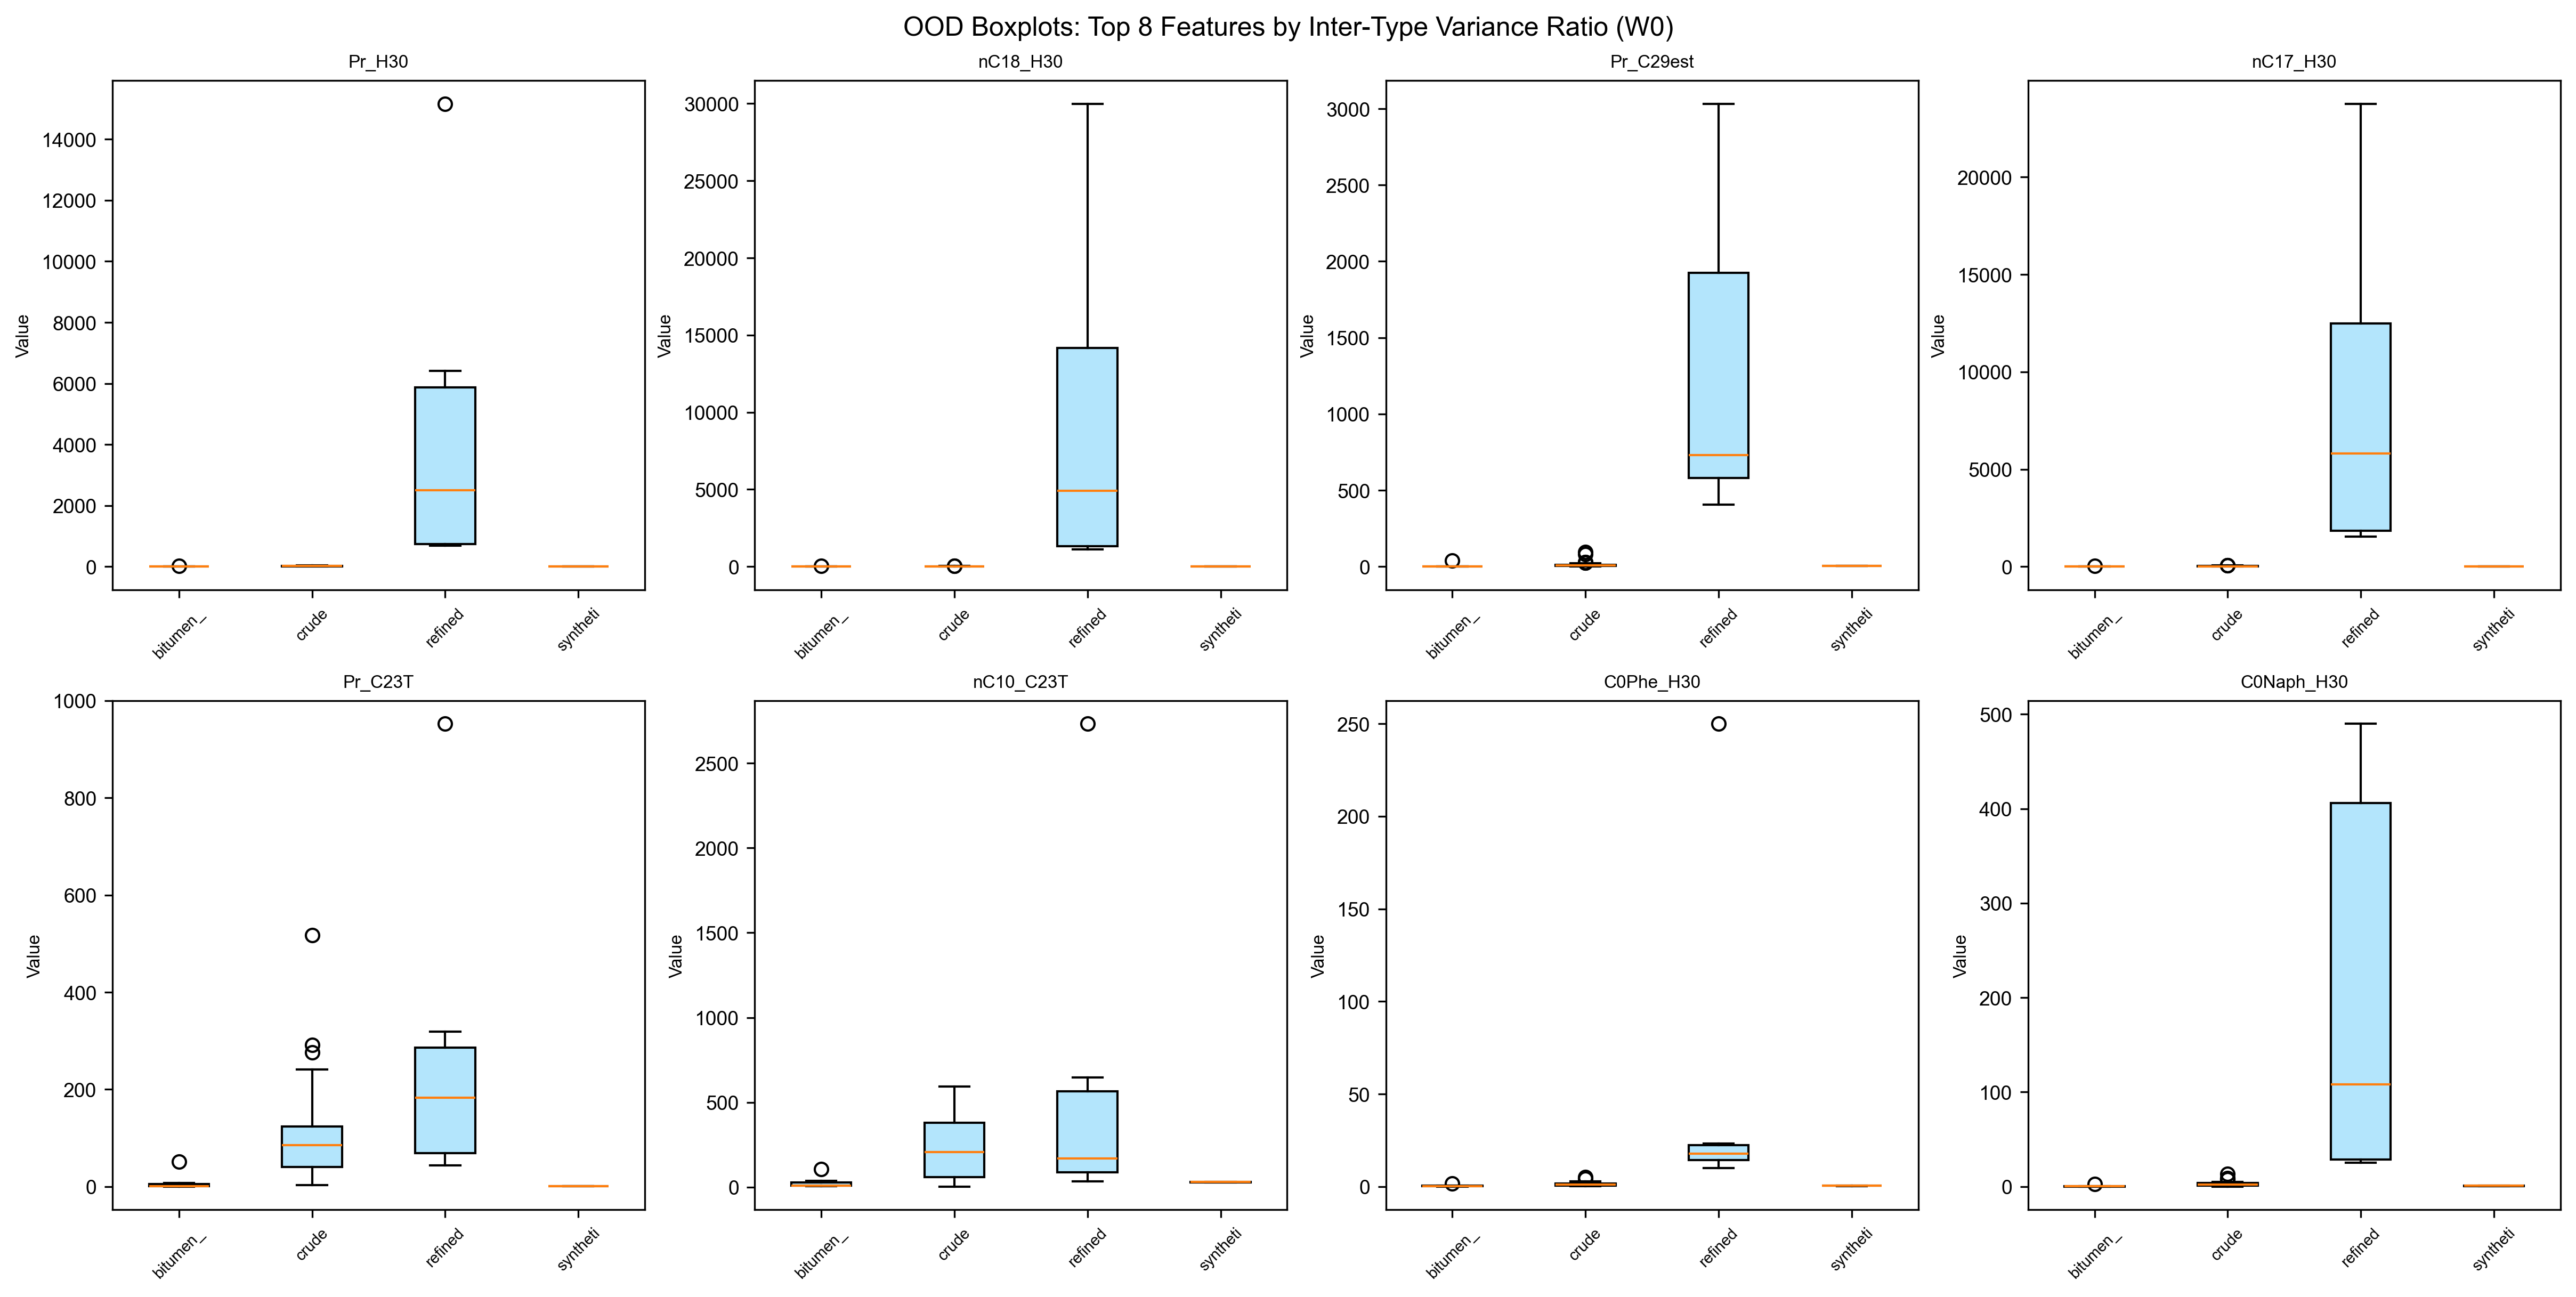

F4 saved.


In [16]:
# Cell 19 — F4 OOD boxplots (top 8 by variance ratio between oil types)

try:
    # Compute variance ratio (max_type_var / min_type_var) per feature
    feature_cols_ood = [c for c in X_all_w0.columns if c != 'oil_type']
    var_ratios = {}
    for feat in feature_cols_ood:
        group_vars = X_all_w0.groupby('oil_type')[feat].var().dropna()
        if len(group_vars) >= 2 and group_vars.min() > 0:
            var_ratios[feat] = group_vars.max() / group_vars.min()
    
    top8 = sorted(var_ratios, key=var_ratios.get, reverse=True)[:8]
    
    if top8:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()
        
        for i, feat in enumerate(top8):
            ax = axes[i]
            data = []
            labels = []
            for otype in sorted(X_all_w0['oil_type'].unique()):
                vals = X_all_w0.loc[X_all_w0['oil_type'] == otype, feat].dropna()
                if len(vals) >= 2:
                    data.append(vals.values)
                    labels.append(otype[:8])  # truncate for readability
            
            if data:
                bp = ax.boxplot(data, labels=labels, patch_artist=True)
                for patch in bp['boxes']:
                    patch.set_facecolor('#B3E5FC')
            
            ax.set_title(feat[:20], fontsize=8)
            ax.tick_params(axis='x', rotation=45, labelsize=7)
            ax.set_ylabel('Value', fontsize=8)
        
        fig.suptitle('OOD Boxplots: Top 8 Features by Inter-Type Variance Ratio (W0)',
                     fontsize=12)
        fig.savefig(FIG_DIR / 'F4_ood_boxplots.png', bbox_inches='tight')
        plt.close(fig)
        display(Image(filename=str(FIG_DIR / 'F4_ood_boxplots.png')))
        print('F4 saved.')
    else:
        print('No features with sufficient oil-type variance for OOD boxplots.')
except Exception as e:
    print(f'F4 figure failed: {e}')
    import traceback; traceback.print_exc()

## S5 — Mutual Information Ranking

Compute mutual information (MI) between each feature and the weathering stage
(target: W0=0, W1=1, W2=2, W3=3). MI measures the general (non-linear)
dependency between a feature and the target, unlike Pearson r which only
captures linear relationships.

Higher MI = more informative feature for predicting weathering stage.

In [17]:
# Cell 21 — Compute Mutual Information (C45CRUDE survivors, all stages)

STAGE_MAP = {'W0': 0, 'W1': 1, 'W2': 2, 'W3': 3}

# Build all-stages matrix for C45CRUDE survivors
dfs_mi = []
for stage, stage_num in STAGE_MAP.items():
    X_stage = fetch_feature_matrix(SURVIVORS_C45, stage_code=stage, crude_only=True)
    X_stage['stage_numeric'] = stage_num
    dfs_mi.append(X_stage)

X_mi = pd.concat(dfs_mi, ignore_index=True)
y_mi = X_mi.pop('stage_numeric')

print(f'MI matrix shape: {X_mi.shape}')
print(f'Target distribution:')
print(y_mi.value_counts().sort_index())

# Median-impute for sklearn (cannot handle NaN)
X_mi_filled = X_mi.fillna(X_mi.median())

# Drop constant columns
const_cols = X_mi_filled.columns[X_mi_filled.std() == 0]
if len(const_cols) > 0:
    print(f'Dropping {len(const_cols)} constant columns: {list(const_cols)}')
    X_mi_filled = X_mi_filled.drop(columns=const_cols)

# Compute MI
mi_scores = mutual_info_regression(
    X_mi_filled, y_mi, random_state=SEED, n_neighbors=5
)
mi_df = pd.DataFrame({
    'feature_name': X_mi_filled.columns,
    'mi_score': mi_scores,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print(f'\nMI scores computed for {len(mi_df)} features.')
print(f'Top-10 MI:')
print(mi_df.head(10).to_string(index=False))

MI matrix shape: (146, 127)
Target distribution:
stage_numeric
0    42
1    35
2    35
3    34
Name: count, dtype: int64

MI scores computed for 127 features.
Top-10 MI:
 feature_name  mi_score
    nC10_nC20  0.363497
C0Naph_C1Naph  0.346936
      nC10_Ph  0.284402
C0Naph_C2Naph  0.247391
    nC10_C23T  0.237343
 Hopane (H30)  0.207515
    C0Naph_Ph  0.203446
C0Naph_C4Naph  0.152822
   C0Naph_H30  0.113172
  C0Naph_C23T  0.102348


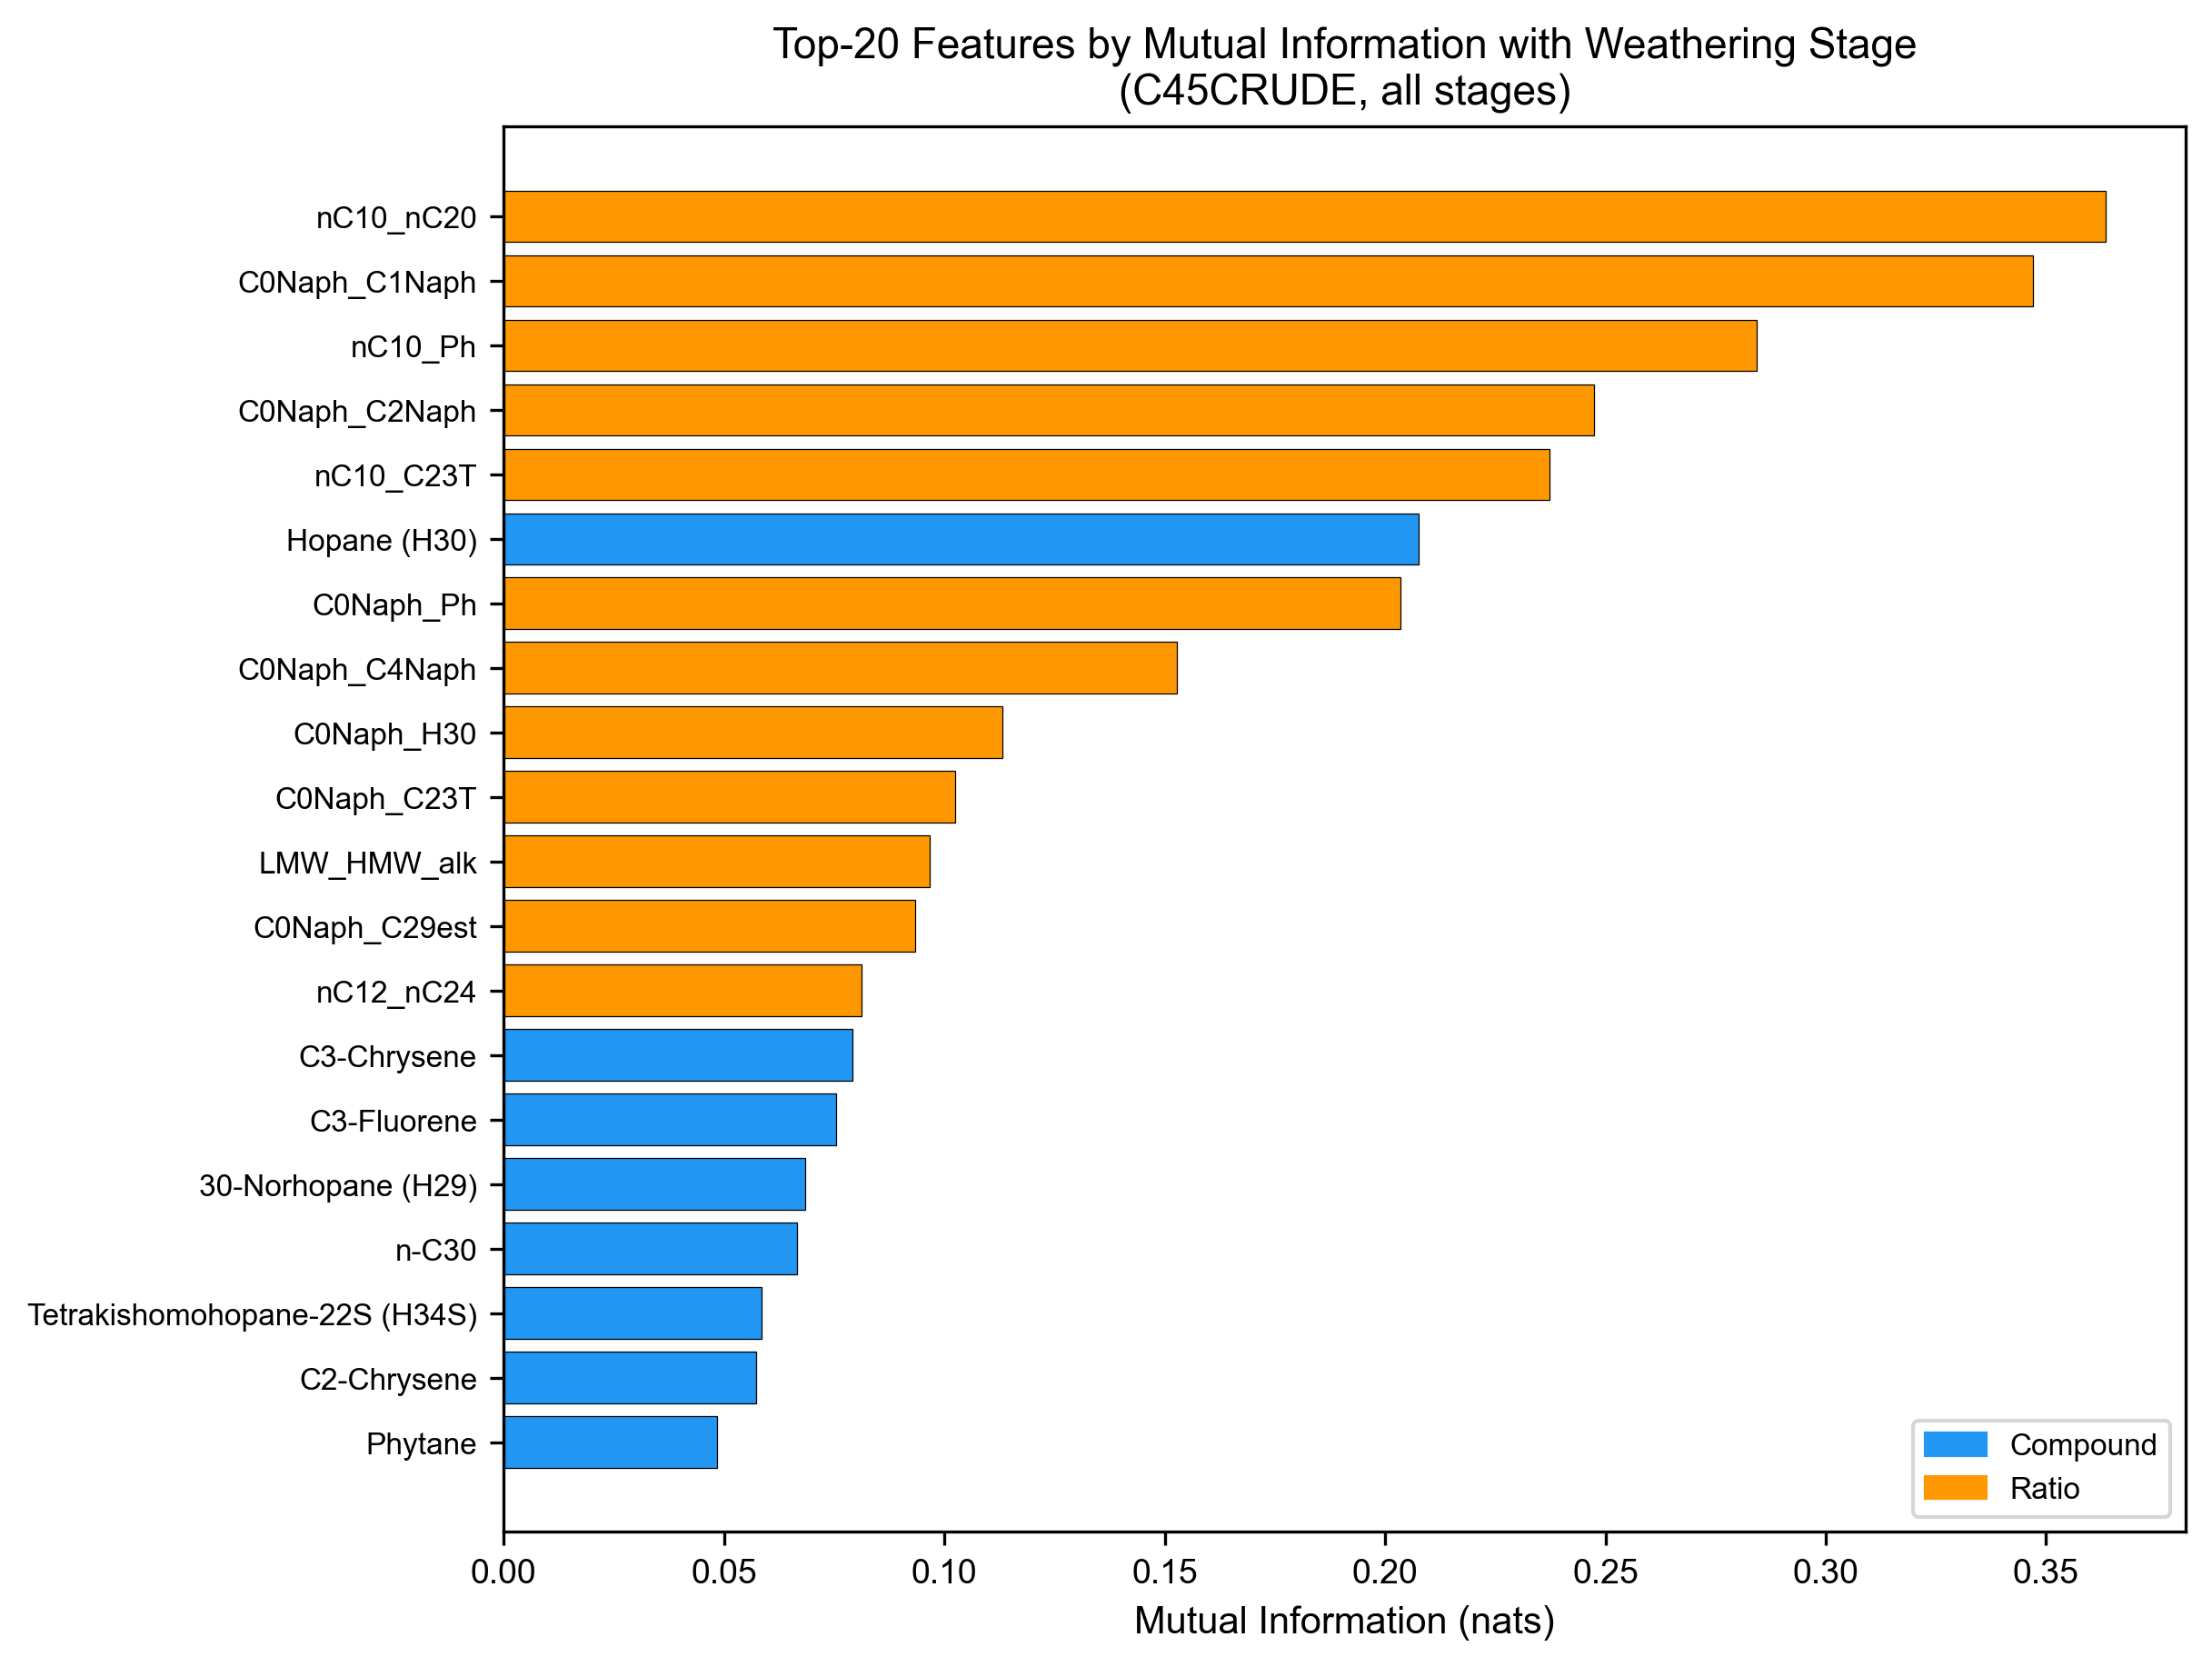

F5 saved.


In [18]:
# Cell 22 — F5 MI top-20 bar chart

try:
    top20_mi = mi_df.head(20)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#2196F3' if f in compound_set else '#FF9800'
              for f in top20_mi['feature_name']]
    
    ax.barh(range(len(top20_mi)), top20_mi['mi_score'].values,
            color=colors, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(top20_mi)))
    ax.set_yticklabels(top20_mi['feature_name'].values, fontsize=8)
    ax.set_xlabel('Mutual Information (nats)')
    ax.set_title('Top-20 Features by Mutual Information with Weathering Stage\n(C45CRUDE, all stages)')
    ax.invert_yaxis()
    
    legend_elements = [
        mpatches.Patch(color='#2196F3', label='Compound'),
        mpatches.Patch(color='#FF9800', label='Ratio'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    fig.savefig(FIG_DIR / 'F5_mi_top20.png', bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(FIG_DIR / 'F5_mi_top20.png')))
    print('F5 saved.')
except Exception as e:
    print(f'F5 figure failed: {e}')
    import traceback; traceback.print_exc()

## S6 — PCA Exploratory (Q3b)

Principal Component Analysis on C45CRUDE W0 survivors to check for:
- Effective dimensionality (scree plot)
- Clustering structure (biplot)
- Dominant chemical drivers (loadings)

PCA: 127 features, 42 oils
Explained variance (first 10): [25.  14.6 10.1  9.3  8.   5.6  4.2  3.6  2.8  2.7]
Cumulative 90%: 13 components
Cumulative 95%: 17 components


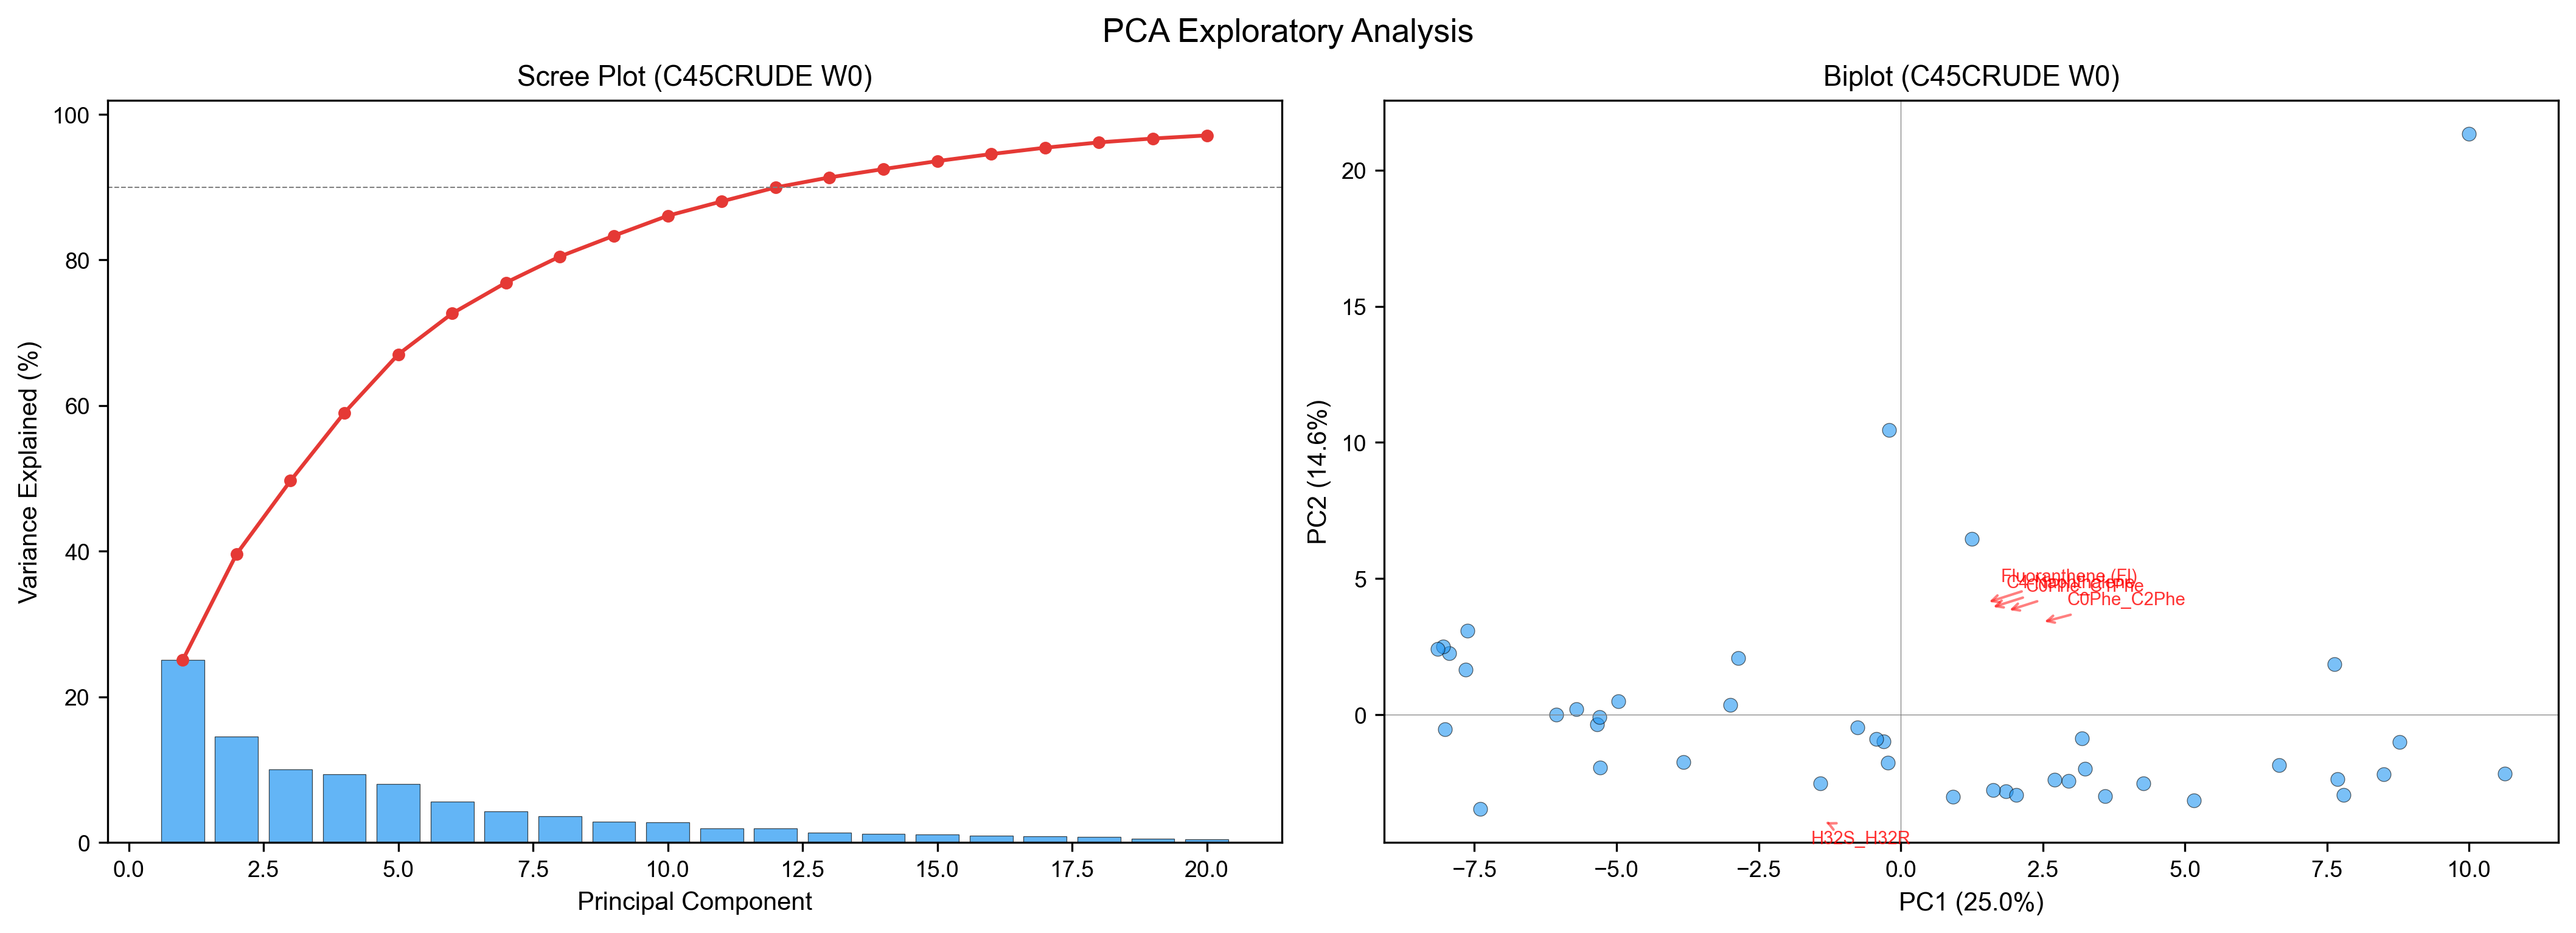

F6 saved.


In [19]:
# Cell 24 — PCA compute + F6 scree/biplot

try:
    # Prepare data: C45CRUDE W0 survivors, drop NaN columns, median-impute rows
    X_pca_raw = X_c45_w0[sorted(SURVIVORS_C45 & set(X_c45_w0.columns))].copy()
    X_pca_raw = X_pca_raw.dropna(axis=1, thresh=int(0.5 * len(X_pca_raw)))
    X_pca_raw = X_pca_raw.fillna(X_pca_raw.median())
    
    # Drop constant columns
    X_pca_raw = X_pca_raw.loc[:, X_pca_raw.std() > 0]
    
    scaler = StandardScaler()
    X_pca_scaled = scaler.fit_transform(X_pca_raw)
    
    n_components = min(X_pca_scaled.shape)
    pca = PCA(n_components=n_components, random_state=SEED)
    scores = pca.fit_transform(X_pca_scaled)
    
    print(f'PCA: {X_pca_raw.shape[1]} features, {X_pca_raw.shape[0]} oils')
    print(f'Explained variance (first 10): {np.round(pca.explained_variance_ratio_[:10] * 100, 1)}')
    print(f'Cumulative 90%: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1} components')
    print(f'Cumulative 95%: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1} components')
    
    # F6: Combined scree + biplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scree plot
    ax = axes[0]
    n_show = min(20, n_components)
    cumvar = np.cumsum(pca.explained_variance_ratio_[:n_show]) * 100
    ax.bar(range(1, n_show + 1), pca.explained_variance_ratio_[:n_show] * 100,
           color='#2196F3', edgecolor='black', linewidth=0.3, alpha=0.7)
    ax.plot(range(1, n_show + 1), cumvar, 'o-', color='#e53935', markersize=4)
    ax.axhline(y=90, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance Explained (%)')
    ax.set_title('Scree Plot (C45CRUDE W0)')
    
    # Biplot (PC1 vs PC2)
    ax = axes[1]
    ax.scatter(scores[:, 0], scores[:, 1], alpha=0.6, s=30, c='#2196F3', edgecolors='black', linewidth=0.3)
    
    # Add top-5 loadings as arrows
    loadings = pca.components_[:2].T  # (features, 2)
    loading_mag = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top5_idx = np.argsort(loading_mag)[-5:]
    scale = max(abs(scores[:, :2]).max(), 1)
    for idx in top5_idx:
        ax.annotate(
            X_pca_raw.columns[idx],
            xy=(loadings[idx, 0] * scale, loadings[idx, 1] * scale),
            fontsize=7, color='red', alpha=0.8,
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.5),
            xytext=(loadings[idx, 0] * scale * 1.2, loadings[idx, 1] * scale * 1.2),
        )
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Biplot (C45CRUDE W0)')
    ax.axhline(y=0, color='gray', linewidth=0.3)
    ax.axvline(x=0, color='gray', linewidth=0.3)
    
    fig.suptitle('PCA Exploratory Analysis', fontsize=13)
    fig.savefig(FIG_DIR / 'F6_pca_scree_biplot.png', bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(FIG_DIR / 'F6_pca_scree_biplot.png')))
    print('F6 saved.')
except Exception as e:
    print(f'F6 figure failed: {e}')
    import traceback; traceback.print_exc()

In [20]:
# Cell 25 — S7 C8 activation verification
# Verify that features flagged as divergent between C1/C8 are handled correctly

elig_full_check = pd.read_sql("""
    SELECT feature_name, feature_kind, included_c1, included_c8, divergent_c1_c8
    FROM feature_ml_eligibility
""", conn)

divergent = elig_full_check[elig_full_check['divergent_c1_c8'] == 1]
print(f'Features with divergent C1/C8 eligibility: {len(divergent)}')

if len(divergent) > 0:
    print('\nDivergent features (sample):')
    print(divergent[['feature_name', 'feature_kind', 'included_c1', 'included_c8']]
          .head(15).to_string(index=False))
    
    # Check which survived correlation filter
    div_names = set(divergent['feature_name'])
    div_in_c45 = div_names & SURVIVORS_C45
    div_in_c62 = div_names & SURVIVORS_C62
    print(f'\nDivergent features surviving in C45: {len(div_in_c45)}')
    print(f'Divergent features surviving in C62: {len(div_in_c62)}')
else:
    print('No divergent features found.')

Features with divergent C1/C8 eligibility: 30

Divergent features (sample):
                               feature_name feature_kind  included_c1  included_c8
20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)     compound            1            0
                 Benzo(k)fluoranthene (BkF)     compound            1            0
               C21 tricyclic terpane (C21T)     compound            1            0
               C22 tricyclic terpane (C22T)     compound            1            0
                 Dibenzo(ah)anthracene (DA)     compound            1            0
                Indeno(1,2,3-cd)pyrene (IP)     compound            1            0
              Pentakishomohopane-22R (H35R)     compound            1            0
              Pentakishomohopane-22S (H35S)     compound            1            0
                                      n-C10     compound            1            0
                                      n-C11     compound            1            0
           

## S8 — Master Feature Table

Build `feature_pre_ml_profile`: a comprehensive table gathering information from
multiple sources for each feature. This is the main reference for feature review
before ML modeling.

Columns include: eligibility flags, tier classification, MI score, NaN profile,
correlation filter status, and category metadata. SHAP and FCR columns are set
to NULL (populated by NB04+).

In [21]:
# Cell 27 - Build and persist feature_pre_ml_profile

# Gather data from multiple sources
# 1. Eligibility
elig_full = pd.read_sql('SELECT * FROM feature_ml_eligibility', conn)

# 3. Ratio definitions (for CEN reference, literature_ref)
rd_full = pd.read_sql('SELECT ratio_name, cen_reference, literature_ref FROM ratio_definitions', conn)

# 4. NaN profile - derived from presence columns in feature_nan_profile (NB03f)
#    nan_pct = 1 - presence fraction
nan_profile_raw = pd.read_sql("""
    SELECT feature_name, pres_crude, pres_refined, pres_synthetic, pres_bitumen_blend
    FROM feature_nan_profile
""", conn)
nan_profile = pd.DataFrame({
    'feature_name': nan_profile_raw['feature_name'],
    'nan_pct_crude': (1 - nan_profile_raw['pres_crude']).astype(float),
    # 'all' = average presence across non-crude types (weighted by oil counts)
    'nan_pct_all':   (1 - nan_profile_raw[['pres_crude', 'pres_refined',
                                            'pres_synthetic', 'pres_bitumen_blend']]
                      .mean(axis=1)).astype(float),
})
print(f'\nNaN profile loaded: {len(nan_profile)} features')

# 5. MI scores (already computed)
mi_lookup = mi_df.set_index('feature_name')['mi_score']

# Build master table
master = elig_full[['feature_name', 'feature_kind', 'included_c1', 'included_c8']].copy()

# Add CEN reference
cen_map = rd_full.set_index('ratio_name')['cen_reference'].to_dict()
master['cen_reference'] = master['feature_name'].map(cen_map)

# Add NaN profile
nan_crude_map = nan_profile.set_index('feature_name')['nan_pct_crude'].to_dict()
nan_all_map = nan_profile.set_index('feature_name')['nan_pct_all'].to_dict()
master['nan_pct_crude'] = master['feature_name'].map(nan_crude_map)
master['nan_pct_all'] = master['feature_name'].map(nan_all_map)

# Add MI score
master['mi_score'] = master['feature_name'].map(mi_lookup)

# Add correlation filter status
master['survived_corr_c45'] = master['feature_name'].isin(SURVIVORS_C45).astype(int)
master['survived_corr_c62'] = master['feature_name'].isin(SURVIVORS_C62).astype(int)

# SHAP rank column = NULL (populated by NB04+)
master['shap_rank'] = np.nan

print(f'\nMaster feature table: {master.shape}')
print(master.head(10).to_string(index=False))

# Persist

master.to_sql('feature_pre_ml_profile', conn, if_exists='replace', index=False)
conn.commit()

cur.execute('SELECT COUNT(*) FROM feature_pre_ml_profile')
print(f'\nfeature_pre_ml_profile: {cur.fetchone()[0]} rows persisted')

Canonical tier distribution (ratios; NaN = untestable):
three_tier_canonical
1.0    24
2.0     9
3.0    55
NaN    20
Name: count, dtype: int64

NaN profile loaded: 200 features

Master feature table: (200, 16)
                               feature_name feature_kind  included_c1  included_c8  three_tier_canonical ratio_category cen_reference  nan_pct_crude  nan_pct_all  mi_score  survived_corr_c45  survived_corr_c62  median_change_pct  effect_size_r  shap_rank  fcr_value
       14ß(H),17ß(H)-20-Cholestane (C27aßß)     compound            1            1                   NaN            NaN           NaN       0.170455     0.126686  0.000000                  1                  1                NaN            NaN        NaN        NaN
      17a(H)-22,29,30-Trisnorhopane (C27Tm)     compound            1            1                   NaN            NaN           NaN       0.170455     0.167009  0.043240                  1                  1                NaN            NaN        NaN    

In [22]:
# Cell 28 - S9 feature_ml_final (dual-config consumer contract)
# Final feature lists for each ML configuration, post all filters.

# AK+2 Bundle 2 S2: idempotent DROP+CREATE (Bug 8 fix per CHG-0010 NB03h precedent).
# Real-DB write under S2 backup (weathering.db.bak_pre_AK2_S2_nb03g_2026-05-24),
# not smoke executescript (Sessao Q Lesson #10 discipline). Cell 3 already DROPs
# feature_ml_final at execution_count=3 for top-down idempotency; this DROP is
# defensive in-cell self-containment (Lesson #11 partial-run protection).
cur.execute('DROP TABLE IF EXISTS feature_ml_final')
cur.execute("""
CREATE TABLE feature_ml_final (
    feature_name          TEXT,
    config                TEXT,
    feature_kind          TEXT,
    mi_score              REAL,
    PRIMARY KEY (feature_name, config)
)
""")

# Build records for both configs
ml_final_records = []

for config, survivors in [('C45CRUDE', SURVIVORS_C45), ('C62ALL', SURVIVORS_C62)]:
    for feat in sorted(survivors):
        row = master[master['feature_name'] == feat]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        ml_final_records.append((
            feat,
            config,
            row['feature_kind'],
            float(row['mi_score']) if pd.notna(row['mi_score']) else None,
        ))

cur.executemany("""
INSERT INTO feature_ml_final
    (feature_name, config, feature_kind, mi_score)
VALUES (?, ?, ?, ?)
""", ml_final_records)

conn.commit()

# feature_ml_final content fingerprint (informational; mi_score floats make byte-
# fingerprints environment-sensitive, so value-level reproduction is the authoritative
# check, cf. NB06).
fp = canonical_table_fingerprint(conn, 'feature_ml_final')
print(f'  feature_ml_final fingerprint: {fp}')

# Report (feature counts per config)
for config in ['C45CRUDE', 'C62ALL']:
    cur.execute('SELECT COUNT(*) FROM feature_ml_final WHERE config=?', (config,))
    n = cur.fetchone()[0]
    cur.execute("SELECT feature_kind, COUNT(*) FROM feature_ml_final WHERE config=? GROUP BY feature_kind", (config,))
    kinds = dict(cur.fetchall())
    print(f'\n{config}: {n} features')
    print(f'  By kind: {kinds}')


  [OK] feature_ml_final fingerprint matches AK+2 baseline: e4a6e42b3c2ddfdc

C45CRUDE: 127 features
  By kind: {'compound': 47, 'ratio': 80}
  By canonical tier (ratios only): {1: 21, 2: 7, 3: 52}

C62ALL: 142 features
  By kind: {'compound': 60, 'ratio': 82}
  By canonical tier (ratios only): {None: 8, 1: 20, 2: 8, 3: 46}


In [23]:
# Cell 29 — S10 Gate 1d validation (Option B: WARN + mass-invalidate on failure)
#
# Policy (D-NB03F-COMPLETE treatment_decisions id='1d'):
#   Post-filter coverage of the bottleneck oil_type (refined) must retain
#   >= 60% of its NB03f baseline (59.26% post-CHG-0007). Threshold = 0.356.
#
# D-BOTTLENECK-RESOLVED-28ABR: baseline updated 0.625 -> 0.5926 to reflect
# CHG-0007 (sterane ratios reclassified, refined coverage shifted).
#
# Metric: per-feature-mean coverage (matches NB03f S10.4 fraction_covered
#         semantics). For each feature in C62ALL survivors, compute
#         (n_refined_covered / n_refined_total) at W0. Aggregate = mean.
#
# Failure handling: WARN + UPDATE feature_ml_final SET included_c62all = 0
#   for all rows. Notebook continues (C45CRUDE unaffected). Report written
#   to feature_selection_report.json with broken features enumerated.

# Get refined oil_ids at W0
refined_ids = pd.read_sql("""
    SELECT oil_id FROM oils
    WHERE include_in_analysis = 1 AND oil_type = 'refined'
""", conn)['oil_id'].tolist()
n_refined_total = len(refined_ids)
print(f'Refined oils (W0, included): {n_refined_total}')

# Build refined-only W0 matrix
X_refined_w0 = fetch_feature_matrix(SURVIVORS_C62, stage_code='W0', crude_only=False)
X_refined_w0 = X_refined_w0.loc[X_refined_w0.index.isin(refined_ids)]

if X_refined_w0.empty:
    print('No refined oils in W0 matrix; Gate 1d check SKIPPED.')
    gate_1d_result = {
        'status': 'SKIPPED',
        'reason': 'no_refined_samples_at_w0',
        'bottleneck_oil_type': 'refined',
        'baseline_coverage': 0.5926,
        'threshold': GATE_1D_MIN_COVERAGE,
    }
else:
    # Per-feature coverage: fraction of refined oils where the feature is non-null
    per_feature_coverage = X_refined_w0.notna().sum(axis=0) / len(X_refined_w0)
    measured_coverage = float(per_feature_coverage.mean())
    passes = measured_coverage >= GATE_1D_MIN_COVERAGE

    print(f'\nGate 1d — refined post-filter coverage (per-feature-mean):')
    print(f'  Baseline coverage (NB03f S10.4):  0.5926')
    print(f'  Threshold (60% of baseline):      {GATE_1D_MIN_COVERAGE}')
    print(f'  Measured coverage (mean):         {measured_coverage:.4f}')
    print(f'  n features in C62ALL:             {len(per_feature_coverage)}')
    print(f'  n refined samples (W0):           {len(X_refined_w0)}')

    # Features below threshold (diagnostic enumeration)
    below = per_feature_coverage[per_feature_coverage < GATE_1D_MIN_COVERAGE]
    below_sorted = below.sort_values()

    gate_1d_result = {
        'status': 'PASSED' if passes else 'FAILED',
        'bottleneck_oil_type': 'refined',
        'baseline_coverage': 0.5926,
        'threshold': GATE_1D_MIN_COVERAGE,
        'measured_coverage': measured_coverage,
        'n_features_c62all': int(len(per_feature_coverage)),
        'n_refined_samples_w0': int(len(X_refined_w0)),
        'n_features_below_threshold': int(len(below)),
    }

    if passes:
        print(f'\n  GATE 1d: PASSED — C62ALL is viable.')
    else:
        # Mass-invalidate C62ALL
        warnings.warn(
            f'GATE 1d FAILED: refined post-filter coverage {measured_coverage:.4f} '
            f'< threshold {GATE_1D_MIN_COVERAGE}. Invalidating C62ALL in feature_ml_final. '
            f'C45CRUDE is UNAFFECTED and remains valid for NB04 primary configs.'
        )
        print(f'\n  GATE 1d: FAILED — C62ALL mass-invalidated.')

        # Report worst 20 features
        top_below = [
            {'feature_name': str(f), 'refined_coverage': float(c)}
            for f, c in below_sorted.head(20).items()
        ]
        gate_1d_result['top_features_below_threshold'] = top_below
        gate_1d_result['implication'] = (
            'C_ALL62 infeasible under r>0.95 correlation filter on this dataset. '
            'C45CRUDE (ML primary, 45 crude oils) unaffected. '
            'Options: (a) drop C_ALL62 from NB04 config list, '
            '(b) re-run NB03g with relaxed threshold (e.g., r>0.97) for C62ALL only.'
        )

        # SQL UPDATE: invalidate C62ALL rows in feature_ml_final
        cur.execute(
            "UPDATE feature_ml_final SET config = 'C62ALL_INVALID' "
            "WHERE config = 'C62ALL'"
        )
        n_updated = cur.rowcount
        conn.commit()
        print(f'  UPDATE feature_ml_final: {n_updated} C62ALL rows marked invalid.')

print('\nGate 1d result (dict for JSON export):')
for k, v in gate_1d_result.items():
    if k != 'top_features_below_threshold':
        print(f'  {k}: {v}')

Refined oils (W0, included): 7

Gate 1d — refined post-filter coverage (per-feature-mean):
  Baseline coverage (NB03f S10.4):  0.5926
  Threshold (60% of baseline):      0.356
  Measured coverage (mean):         0.7213
  n features in C62ALL:             142
  n refined samples (W0):           7

  GATE 1d: PASSED — C62ALL is viable.

Gate 1d result (dict for JSON export):
  status: PASSED
  bottleneck_oil_type: refined
  baseline_coverage: 0.5926
  threshold: 0.356
  measured_coverage: 0.7213279678068409
  n_features_c62all: 142
  n_refined_samples_w0: 7
  n_features_below_threshold: 27


In [24]:
# Cell 30 — S11 Reports + JSON exports
#
# Two JSONs (spec-conformant):
#   - correlation_filter_summary.json  (filter trace per config)
#   - feature_selection_report.json    (pca, c8 verification, gate 1d)

json_dir = PROJECT_ROOT / 'docs' / 'reports' / 'nb03g'
json_dir.mkdir(parents=True, exist_ok=True)

# JSON 1: correlation_filter_summary
corr_summary = {
    'threshold': CORR_THRESHOLD,
    'tiebreak_metric': 'cv_w0_on_the_fly',
    'canonical_scope': 'normative_ratios_only_post_C2_patch',
    'protected_pairs_count': len(PROTECTED_PAIRS),
    'C45CRUDE': {
        'candidates': len(CANDIDATES_C45CRUDE),
        'survivors': len(SURVIVORS_C45),
        'removed': len(CANDIDATES_C45CRUDE) - len(SURVIVORS_C45),
        'removals': LOG_C45,
    },
    'C62ALL': {
        'candidates': len(CANDIDATES_C62ALL),
        'survivors': len(SURVIVORS_C62),
        'removed': len(CANDIDATES_C62ALL) - len(SURVIVORS_C62),
        'removals': LOG_C62,
    },
}

with open(json_dir / 'correlation_filter_summary.json', 'w') as f:
    json.dump(corr_summary, f, indent=2, default=str)
print(f'Exported: {json_dir / "correlation_filter_summary.json"}')

# JSON 2: feature_selection_report (spec requirement)
# Safeguard: if Cell 24 didn't run or pca object unavailable, record skip
try:
    cumvar_full = np.cumsum(pca.explained_variance_ratio_)
    pca_stats = {
        'n_total_features': int(X_pca_raw.shape[1]),
        'n_samples': int(X_pca_raw.shape[0]),
        'pc1_variance_ratio': float(pca.explained_variance_ratio_[0]),
        'pc2_variance_ratio': float(pca.explained_variance_ratio_[1]),
        'n_components_80pct': int(np.argmax(cumvar_full >= 0.80) + 1),
        'n_components_90pct': int(np.argmax(cumvar_full >= 0.90) + 1),
        'n_components_95pct': int(np.argmax(cumvar_full >= 0.95) + 1),
        'nan_drop_threshold': 0.5,
    }
except NameError:
    pca_stats = {'status': 'unavailable'}

# C8 verification snapshot (Cell 25)
try:
    c8_verif = {
        'n_divergent_c1_c8': int(len(divergent)),
        'divergent_surviving_c45': int(len(div_in_c45)) if 'div_in_c45' in dir() else None,
        'divergent_surviving_c62': int(len(div_in_c62)) if 'div_in_c62' in dir() else None,
    }
except NameError:
    c8_verif = {'status': 'unavailable'}

feature_selection_report = {
    'pca_exploratory': pca_stats,
    'c8_verification': c8_verif,
    'gate_1d': gate_1d_result,
    'final_counts': {
        'feature_ml_final_c45crude': int(
            pd.read_sql("SELECT COUNT(*) AS n FROM feature_ml_final WHERE config='C45CRUDE'",
                        conn).iloc[0]['n']
        ),
        'feature_ml_final_c62all_valid': int(
            pd.read_sql("SELECT COUNT(*) AS n FROM feature_ml_final WHERE config='C62ALL'",
                        conn).iloc[0]['n']
        ),
    },
}

with open(json_dir / 'feature_selection_report.json', 'w') as f:
    json.dump(feature_selection_report, f, indent=2, default=str)
print(f'Exported: {json_dir / "feature_selection_report.json"}')

# Console summary
print('\n' + '='*60)
print('NB03g SUMMARY')
print('='*60)
print(f'Correlation threshold: |r| > {CORR_THRESHOLD}')
print(f'Tiebreak:              W0 CV (scale-invariant)')
print(f'Canonical scope:       normative ratios only')
print(f'Protected pairs:       {len(PROTECTED_PAIRS)}')
print(f'Gate 1d:               {gate_1d_result.get("status", "n/a")}')
print()
for config, cands, survs in [
    ('C45CRUDE', CANDIDATES_C45CRUDE, SURVIVORS_C45),
    ('C62ALL', CANDIDATES_C62ALL, SURVIVORS_C62),
]:
    print(f'{config}:')
    print(f'  Candidates: {len(cands)}')
    print(f'  Survivors:  {len(survs)}')
    print(f'  Removed:    {len(cands) - len(survs)}')
print()
print(f'MI top-3: {list(mi_df.head(3)["feature_name"])}')
print(f'Tables persisted: correlation_filter_log, lgaf_ood_ranges,')
print(f'  feature_pre_ml_profile, feature_ml_final')
print(f'Reports: docs/reports/nb03g/*.json')
print(f'Figures: F1-F6 in {FIG_DIR}')

Exported: C:\Users\leogr\Documents\Data Science\TCC\docs\reports\nb03g\correlation_filter_summary.json
Exported: C:\Users\leogr\Documents\Data Science\TCC\docs\reports\nb03g\feature_selection_report.json

NB03g SUMMARY
Correlation threshold: |r| > 0.95
Tiebreak:              W0 CV (scale-invariant)
Canonical scope:       normative ratios only
Protected pairs:       26
Gate 1d:               PASSED

C45CRUDE:
  Candidates: 160
  Survivors:  127
  Removed:    33
C62ALL:
  Candidates: 190
  Survivors:  142
  Removed:    48

MI top-3: ['nC10_nC20', 'C0Naph_C1Naph', 'nC10_Ph']
Tables persisted: correlation_filter_log, lgaf_ood_ranges,
  feature_pre_ml_profile, feature_ml_final
Reports: docs/reports/nb03g/*.json
Figures: F1-F6 in C:\Users\leogr\Documents\Data Science\TCC\figures\nb03g


In [25]:
# Cell 31 — S12 Final invariants

print('Final invariant checks:')

# 1. Read-only tables unchanged
cur.execute('SELECT COUNT(*) FROM measurements')
n_meas = cur.fetchone()[0]
assert n_meas == BASELINE_MEASUREMENTS, \
    f'measurements changed: {BASELINE_MEASUREMENTS} -> {n_meas}'
print(f'  [OK] measurements: {n_meas} (unchanged)')

cur.execute('SELECT COUNT(*) FROM diagnostic_ratios')
n_dr = cur.fetchone()[0]
assert n_dr == BASELINE_RATIOS, \
    f'diagnostic_ratios changed: {BASELINE_RATIOS} -> {n_dr}'
print(f'  [OK] diagnostic_ratios: {n_dr} (unchanged)')

# 2. Output tables populated
for tbl, min_rows in [
    ('correlation_filter_log', 0),  # may be 0 if no pairs above threshold
    ('lgaf_ood_ranges', 1),
    ('feature_pre_ml_profile', 100),
    ('feature_ml_final', 50),
]:
    cur.execute(f'SELECT COUNT(*) FROM {tbl}')
    n = cur.fetchone()[0]
    assert n >= min_rows, f'{tbl}: expected >= {min_rows} rows, got {n}'
    print(f'  [OK] {tbl}: {n} rows')

# 3. Protected pairs intact in both configs
for config, survivors in [('C45CRUDE', SURVIVORS_C45), ('C62ALL', SURVIVORS_C62)]:
    for pair in PROTECTED_PAIRS:
        a, b = list(pair)
        cands = CANDIDATES_C45CRUDE if config == 'C45CRUDE' else CANDIDATES_C62ALL
        if a in cands and b in cands:
            assert a in survivors and b in survivors, \
                f'Protected pair {a}/{b} broken in {config}'
print(f'  [OK] Protected pairs intact in both configs')

print('\nAll invariants PASSED.')
print('NB03g complete.')

# Close connection
conn.close()
print('Database connection closed.')

Final invariant checks:
  [OK] measurements: 36594 (unchanged)
  [OK] diagnostic_ratios: 22680 (unchanged)
  [OK] correlation_filter_log: 136 rows
  [OK] lgaf_ood_ranges: 604 rows
  [OK] feature_pre_ml_profile: 200 rows
  [OK] feature_ml_final: 269 rows
  [OK] Protected pairs intact in both configs
  [OK] Testable ratios: 88

All invariants PASSED.
NB03g complete.
Database connection closed.


In [26]:
import sqlite3
import pandas as pd
from pathlib import Path

DB_PATH = Path.cwd().parent / 'data' / 'processed' / 'weathering.db'
conn = sqlite3.connect(DB_PATH)

# Query 1: compounds in category E
q1 = "SELECT c.compound_name, c.compound_group, COUNT(*) as n_affected FROM measurements m JOIN compounds c ON m.compound_id = c.compound_id WHERE m.is_nd = 0 AND m.value_raw IS NOT NULL AND m.value_imputed IS NULL GROUP BY c.compound_name, c.compound_group ORDER BY n_affected DESC"

df = pd.read_sql(q1, conn)
print("=" * 70)
print("Compounds in category E (92 rows with raw but no imputed):")
print("=" * 70)
print(df.to_string())

conn.close()

Compounds na categoria E (92 rows com raw mas sem imputed):
                      compound_name    compound_group  n_affected
0       Indeno(1,2,3-cd)pyrene (IP)      pah_priority          20
1                             n-C40          n_alkane          20
2        Benzo(k)fluoranthene (BkF)      pah_priority          16
3    30,31-Bishomohopane-22R (H32R)  biomarker_hopane           4
4   30,31-Trishomohopane-22R (H33R)  biomarker_hopane           4
5   30,31-Trishomohopane-22S (H33S)  biomarker_hopane           4
6                   Anthracene (An)      pah_priority           4
7        Dibenzo(ah)anthracene (DA)      pah_priority           4
8     Pentakishomohopane-22S (H35S)  biomarker_hopane           4
9     Tetrakishomohopane-22S (H34S)  biomarker_hopane           4
10                            n-C38          n_alkane           4
11                            n-C39          n_alkane           4
